In [1]:
#%%time
import os
import re
import gzip
import math
import random
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt

from ast import literal_eval
import warnings
# 忽略 FutureWarning 类型警告
warnings.simplefilter(action='ignore', category=FutureWarning)
# 忽略特定类型的警告：忽略 scanpy包中含有 ignore 的 UserWarning 类型警告
warnings.filterwarnings("ignore", category=UserWarning, module="scanpy")
# 禁用 pandas 包中的 SettingWithCopyWarning 类型警告  
pd.options.mode.chained_assignment = None  # 或 'raise' 表示引发异常

import inferECC
from inferECC import *

species value: hg38
species == 'mm10':  False


In [2]:
def get_all_folders(path):
    folders = [f for f in os.listdir(path) if os.path.isdir(os.path.join(path, f))]
    return folders
"""
# 指定路径
target_path = library_dir # '/your/target/directory'
# 获取所有文件夹
folders_list = get_all_folders(target_path)
"""

"\n# 指定路径\ntarget_path = library_dir # '/your/target/directory'\n# 获取所有文件夹\nfolders_list = get_all_folders(target_path)\n"

In [3]:
#python编程，scanpy 处理单细胞数据，
#现有10个cancer文件夹，每个cancer有10-15个sample，
#每个sample文件夹下，有h5ad格式单细胞矩阵，
#计算每个单细胞矩阵的每个基因表达值大于等于6的细胞占比，
#得到每个cancer的每个sample的每个基因的细胞占比统计数据，
#将这些数据存入一个字典格式的对象中，
#然后分别画图可视化每个sample的每个基因大等于6的细胞数量占比统计density曲线图。

In [4]:
import warnings
import scanpy as sc
adata_list = list()
# 忽略来自 scanpy 的警告
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    #all_path = "D:/02.project/18.ecDNA/01.result/result_1k/CRC/"
    #all_path = "D:/02.project/18.ecDNA/01.result/result_htan/htan_atac_merge0.2_pdac/"
    #all_path = "D:/02.project/18.ecDNA/01.result/result_htan/htan_atac_merge0.2_s3/"
    #all_path = "D:/02.project/18.ecDNA/01.result/result_htan/htan_atac_merge0.2_add/"
    all_path = "D:/02.project/18.ecDNA/01.result/result_htan/htan_atac_merge/"
    cancer_list = get_all_folders(all_path)
    for cancer in cancer_list:
        sample_list = get_all_folders(all_path+cancer)
        print(cancer)
        for sample in sample_list:
            lib_dir = all_path+cancer+"/"+sample
            print(lib_dir)
            adata_sample = sc.read(lib_dir+"/ks_uniform_qsub/cellXecDNA_fi.matrix.h5ad")
            # 筛选在大于3个细胞中存在的ecDNA
            #sc.pp.filter_cells(adata_sample, min_genes=3)
            sc.pp.filter_genes(adata_sample, min_cells=3)
            sample = re.sub("(-fragments.tsv.gz|-atac_fragments.tsv.gz)$", "", sample)
            adata_sample.var["cancer"]=cancer
            adata_sample.var["sample"]=sample
            adata_sample.var['ecDNA_CPR'] = adata_sample.var.index
            #cell_frequency_cov6pos = (adata_sample.X >= 6).mean(axis=0)
            #cell_number_cov6pos = (adata_sample.X >= 6).sum(axis=0)
            adata_sample.var['cell_frequency_cov6pos'] = (adata_sample.X >= 6).mean(axis=0)
            adata_sample.var['cell_number_cov6pos'] = (adata_sample.X >= 6).sum(axis=0)
            adata_sample.var['Ave_coverage_in_sample'] = np.mean(adata_sample.X, axis=0)
            adata_sample.var['Median_coverage_in_sample'] = np.median(adata_sample.X, axis=0)
            adata_list.append(adata_sample)
            pass

BRCA
D:/02.project/18.ecDNA/01.result/result_htan/htan_atac_merge/BRCA/ht029b1-s1pc-fragments.tsv.gz
D:/02.project/18.ecDNA/01.result/result_htan/htan_atac_merge/BRCA/ht035b1-s1pa-fragments.tsv.gz
D:/02.project/18.ecDNA/01.result/result_htan/htan_atac_merge/BRCA/ht088b1-s1h1-fragments.tsv.gz
D:/02.project/18.ecDNA/01.result/result_htan/htan_atac_merge/BRCA/ht088b1-s1h2-fragments.tsv.gz
D:/02.project/18.ecDNA/01.result/result_htan/htan_atac_merge/BRCA/ht128b1-s1h4-fragments.tsv.gz
D:/02.project/18.ecDNA/01.result/result_htan/htan_atac_merge/BRCA/ht137b1-s1h7-fragments.tsv.gz
D:/02.project/18.ecDNA/01.result/result_htan/htan_atac_merge/BRCA/ht1408-06-fragments.tsv.gz
D:/02.project/18.ecDNA/01.result/result_htan/htan_atac_merge/BRCA/ht141b1-s1h1-fragments.tsv.gz
D:/02.project/18.ecDNA/01.result/result_htan/htan_atac_merge/BRCA/ht206b1-s1h4-fragments.tsv.gz
D:/02.project/18.ecDNA/01.result/result_htan/htan_atac_merge/BRCA/ht214b1-s1h2-fragments.tsv.gz
D:/02.project/18.ecDNA/01.result/resul

In [5]:
# 统计coverage>=6的ecDNA数量
df_cancer_sample_cpr = pd.DataFrame(columns=["cancer","sample","ecDNA_CPR",
                                             "cell_number_cov6pos","cell_frequency_cov6pos",
                                             "Ave_coverage_in_sample","Max_coverage_in_sample",
                                             "Median_coverage_in_sample"])
# 从 adata_list 对象 adata_sample 中提取每种癌症类型的每个样本的ecDNA数量
for adata_sample in adata_list:
    adata_sample.var['Ave_coverage_in_sample'] = np.mean(adata_sample.X, axis=0)
    adata_sample.var['Max_coverage_in_sample'] = np.max(adata_sample.X, axis=0)
    adata_sample.var['Median_coverage_in_sample'] = np.median(adata_sample.X, axis=0)
    df_temp = adata_sample.var.copy()
    df_cancer_sample_cpr = pd.concat([df_cancer_sample_cpr, df_temp])
    pass
df_cancer_sample_cpr.to_csv('./fig_100k_3/cell_frequency/f00-df_cancer_sample_cpr.xls', sep='\t', index=False)

In [4]:
df_cancer_sample_cpr = pd.read_csv('./fig_100k_3/cell_frequency/f00-df_cancer_sample_cpr.xls', sep='\t')
df_cancer_sample_cpr

,cancer,sample,ecDNA_CPR,cell_number_cov6pos,cell_frequency_cov6pos,Ave_coverage_in_sample,Max_coverage_in_sample,Median_coverage_in_sample,chr_100k,n_cells
0,BRCA,ht029b1-s1pc,chr10:10000000_10100000,3,0.000817,0.006475,8.891147,0.0,chr10:10000000_10100000,3.0
1,BRCA,ht029b1-s1pc,chr10:1000000_1100000,215,0.058583,0.500815,39.768020,0.0,chr10:1000000_1100000,215.0
2,BRCA,ht029b1-s1pc,chr10:100000_200000,18,0.004905,0.040703,17.863032,0.0,chr10:100000_200000,18.0
3,BRCA,ht029b1-s1pc,chr10:100100000_100200000,3,0.000817,0.005242,6.622517,0.0,chr10:100100000_100200000,3.0
4,BRCA,ht029b1-s1pc,chr10:100300000_100400000,5,0.001362,0.011711,13.365410,0.0,chr10:100300000_100400000,5.0
...,...,...,...,...,...,...,...,...,...,...
765038,UCEC,cpt704du-t1,chrX:153900000_154000000,6,0.011650,0.101160,13.002601,0.0,chrX:153900000_154000000,6.0
765039,UCEC,cpt704du-t1,chrX:154300000_154400000,3,0.005825,0.050279,10.220470,0.0,chrX:154300000_154400000,3.0
765040,UCEC,cpt704du-t1,chrX:154400000_154500000,5,0.009709,0.099661,14.542810,0.0,chrX:154400000_154500000,5.0
765041,UCEC,cpt704du-t1,chrX:49100000_49200000,4,0.007767,0.060018,9.803922,0.0,chrX:49100000_49200000,4.0


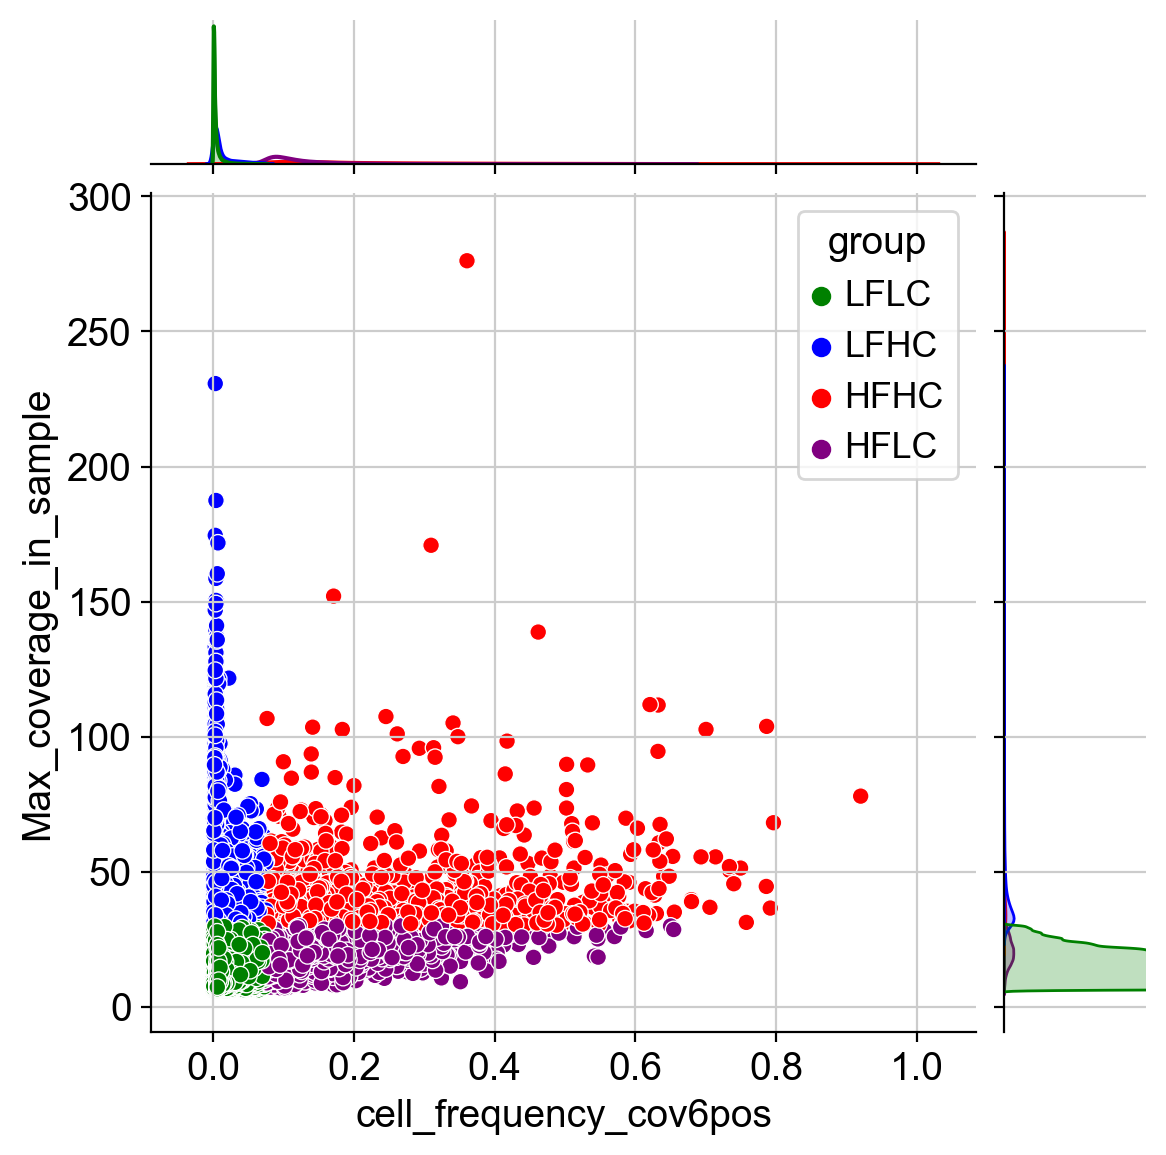

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 假设df_summary是您的DataFrame
#df_cancer_sample_cpr = pd.DataFrame()  # 示例，您需要用您的实际数据替换这里

# 定义列名
x_col = 'cell_frequency_cov6pos'
y_col = "Max_coverage_in_sample"

# 计算最大值和bins
max_value = df_cancer_sample_cpr[x_col].max()
binwidth = (df_cancer_sample_cpr[x_col].max() - df_cancer_sample_cpr[x_col].min()) / 100
bins = np.arange(0, max_value + binwidth, binwidth)

# 定义颜色映射
color_mapping = {
    'HFHC': 'red',
    'HFLC': 'purple',
    'LFHC': 'blue',
    'LFLC': 'green'
}
x_cutoff = df_cancer_sample_cpr[x_col].quantile(0.99) # x_col列的上四分位数
y_cutoff = df_cancer_sample_cpr[y_col].quantile(0.99) # y_col列的上四分位数
# 根据cutoff值分组
def assign_group(row):
    if row[x_col] >= x_cutoff and row[y_col] >= y_cutoff:
        return 'HFHC'
    elif row[x_col] >= x_cutoff and row[y_col] < y_cutoff:
        return 'HFLC'
    elif row[x_col] < x_cutoff and row[y_col] >= y_cutoff:
        return 'LFHC'
    elif row[x_col] < x_cutoff and row[y_col] < y_cutoff:
        return 'LFLC'
# 应用分组函数
df_cancer_sample_cpr['group'] = df_cancer_sample_cpr.apply(assign_group, axis=1)

# 创建jointplot
g = sns.jointplot(data=df_cancer_sample_cpr, x=x_col, y=y_col, hue='group', palette=color_mapping, kind="scatter")
# 设置y轴的限制
plt.xlim(0, 0.01)
#plt.ylim(0, 1)
## 绘制核密度拟合曲线
for group in color_mapping:
    sns.kdeplot(data=df_cancer_sample_cpr[df_cancer_sample_cpr['group'] == group][x_col], ax=g.ax_marg_x, color=color_mapping[group], legend=False)
#    sns.kdeplot(data=df_cancer_sample_cpr[df_cancer_sample_cpr['group'] == group][y_col], ax=g.ax_marg_y, color=color_mapping[group], legend=False)
# 关闭网格线
#plt.grid(False)
# 添加图例
#plt.legend(title='Group', loc='upper right')
# 显示图表
#plt.show()
plt.savefig(f"./fig_100k_3/cell_frequency/f02-df_summary-{y_col}-scatterplot.pdf", bbox_inches='tight')

In [16]:
# 根据'col1'列的值进行分组，并计算每组'col2'列的平均值
cell_frequency_average = df_cancer_sample_cpr.groupby('ecDNA_CPR')['cell_frequency_cov6pos'].mean()
cell_frequency_median = df_cancer_sample_cpr.groupby('ecDNA_CPR')['cell_frequency_cov6pos'].median()
cell_frequency_std = df_cancer_sample_cpr.groupby('ecDNA_CPR')['cell_frequency_cov6pos'].std()
grouped = df_cancer_sample_cpr.groupby('ecDNA_CPR')['cell_frequency_cov6pos'].agg(['mean', 'var']) # 分组计算平均值和方差
cell_frequency_dispersions = grouped['var'] / grouped['mean'] # 计算散度
# 根据'col1'列的值进行分组，并计算每组'col2'列的标准差
Ave_coverage_std = df_cancer_sample_cpr.groupby('ecDNA_CPR')['Ave_coverage_in_sample'].std()
Median_coverage_std = df_cancer_sample_cpr.groupby('ecDNA_CPR')['Median_coverage_in_sample'].std()
grouped = df_cancer_sample_cpr.groupby('ecDNA_CPR')['Ave_coverage_in_sample'].agg(['mean', 'var']) # 分组计算平均值和方差
Ave_coverage_dispersions = grouped['var'] / grouped['mean'] # 计算散度
grouped = df_cancer_sample_cpr.groupby('ecDNA_CPR')['Median_coverage_in_sample'].agg(['mean', 'var']) # 分组计算平均值和方差
Median_coveragee_dispersions = grouped['var'] / grouped['mean'] # 计算散度

# 创建一个新的DataFrame，包含计算得到的平均值和中位数
df_summary = pd.DataFrame({
    'cell_frequency_average': cell_frequency_average,
    'cell_frequency_median': cell_frequency_median,
    'cell_frequency_std': cell_frequency_std,
    'cell_frequency_dispersions': cell_frequency_dispersions,
    'Ave_coverage_std': Ave_coverage_std,
    'Median_coverage_std': Median_coverage_std,
    'Ave_coverage_dispersions': Ave_coverage_dispersions,
    'Median_coveragee_dispersions': Median_coveragee_dispersions
})
df_summary = df_summary.fillna(0)
df_summary.to_csv('./fig_100k_3/cell_frequency/f01-df_cancer_sample_cpr-df_summary.xls', sep='\t', index=True)
df_summary

,cell_frequency_average,cell_frequency_median,cell_frequency_std,cell_frequency_dispersions,Ave_coverage_std,Median_coverage_std,Ave_coverage_dispersions,Median_coveragee_dispersions
ecDNA_CPR,,,,,,,,
chr10:0_100000,0.000877,0.000878,0.000379,0.000164,0.002656,0.0,0.001019,0.0
chr10:100000000_100100000,0.001321,0.001049,0.001069,0.000865,0.009468,0.0,0.008371,0.0
chr10:10000000_10100000,0.001510,0.001034,0.001021,0.000691,0.012676,0.0,0.011104,0.0
chr10:1000000_1100000,0.003832,0.002598,0.006521,0.011095,0.055197,0.0,0.099782,0.0
chr10:100000_200000,0.001569,0.000965,0.001537,0.001505,0.011718,0.0,0.011420,0.0
...,...,...,...,...,...,...,...,...
chrY:8800000_8900000,0.003425,0.003425,0.000000,0.000000,0.000000,0.0,0.000000,0.0
chrY:8900000_9000000,0.002037,0.002037,0.000000,0.000000,0.000000,0.0,0.000000,0.0
chrY:9200000_9300000,0.001527,0.001527,0.000000,0.000000,0.000000,0.0,0.000000,0.0


In [131]:
df_summary = pd.read_csv('./fig_100k_3/cell_frequency/f01-df_cancer_sample_cpr-df_summary.xls', sep='\t', index_col=0)
df_summary

,cell_frequency_average,cell_frequency_median,cell_frequency_std,cell_frequency_dispersions,Ave_coverage_std,Median_coverage_std,Ave_coverage_dispersions,Median_coveragee_dispersions
ecDNA_CPR,,,,,,,,
chr10:0_100000,0.000877,0.000878,0.000379,0.000164,0.002656,0.0,0.001019,0.0
chr10:100000000_100100000,0.001321,0.001049,0.001069,0.000865,0.009468,0.0,0.008371,0.0
chr10:10000000_10100000,0.001510,0.001034,0.001021,0.000691,0.012676,0.0,0.011104,0.0
chr10:1000000_1100000,0.003832,0.002598,0.006521,0.011095,0.055197,0.0,0.099782,0.0
chr10:100000_200000,0.001569,0.000965,0.001537,0.001505,0.011718,0.0,0.011420,0.0
...,...,...,...,...,...,...,...,...
chrY:8800000_8900000,0.003425,0.003425,0.000000,0.000000,0.000000,0.0,0.000000,0.0
chrY:8900000_9000000,0.002037,0.002037,0.000000,0.000000,0.000000,0.0,0.000000,0.0
chrY:9200000_9300000,0.001527,0.001527,0.000000,0.000000,0.000000,0.0,0.000000,0.0


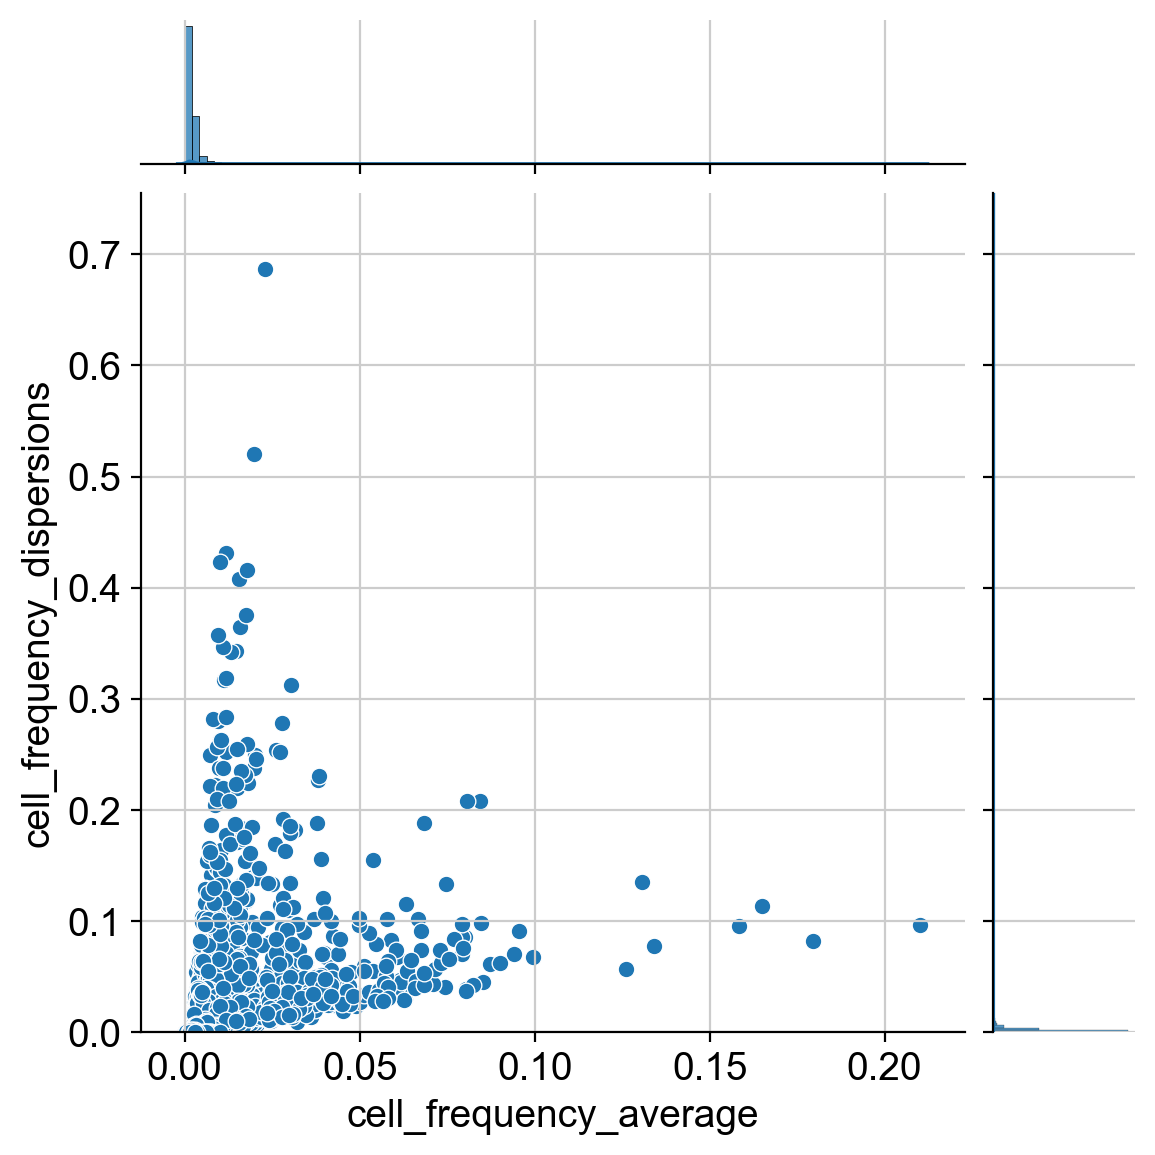

In [132]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 假设df是您的DataFrame，'x_col'和'y_col'是您想要作为坐标轴的列名
x_col = 'cell_frequency_average'
y_col = "cell_frequency_dispersions"

max_value = df_summary[x_col].max()
binwidth=(df_summary[x_col].max()-df_summary[x_col].min())/100
bins = np.arange(0, max_value + binwidth, binwidth)

# 创建一个jointplot，绘制散点图和核密度拟合曲线
g = sns.jointplot(data=df_summary, x=x_col, y=y_col, kind="scatter", marginal_kws=dict(bins=bins, fill=True))
plt.ylim(0, df_summary[y_col].max()*1.1)
# 绘制x轴和y轴的核密度拟合曲线
sns.kdeplot(data=df_summary[x_col], ax=g.ax_marg_x, vertical=True, legend=False)
sns.kdeplot(data=df_summary[y_col], ax=g.ax_marg_y, vertical=True, legend=False)
#plt.grid(False)  # 关闭网格线
# 显示图表
#plt.show()
plt.savefig(f"./fig_100k_3/cell_frequency/f01-df_summary-{y_col}-scatterplot.pdf", bbox_inches='tight')

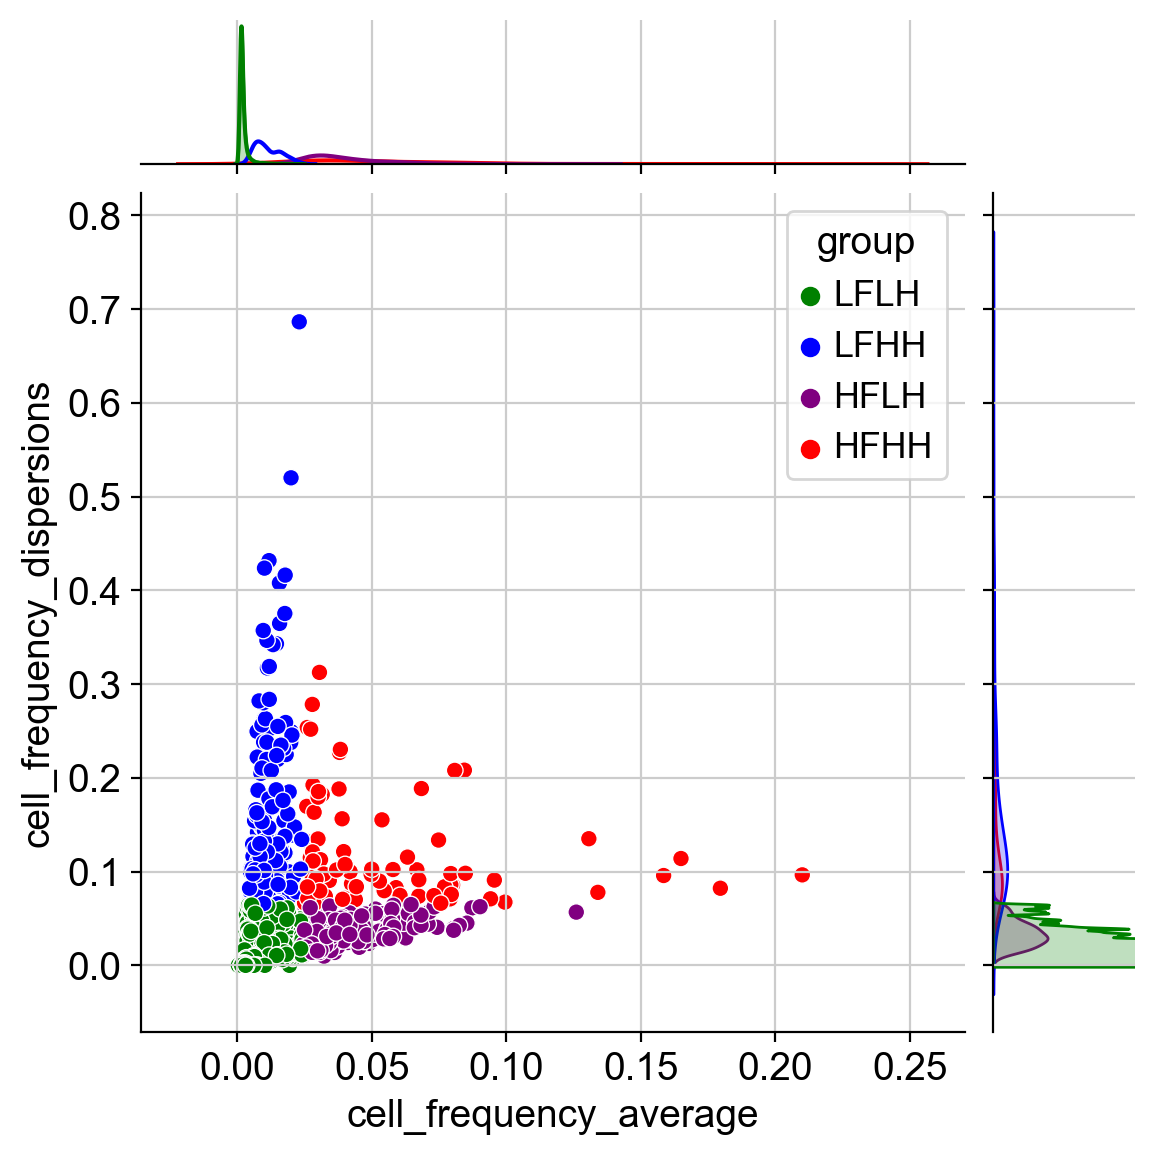

In [93]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 假设df_summary是您的DataFrame
#df_summary = pd.DataFrame()  # 示例，您需要用您的实际数据替换这里

# 定义列名
x_col = 'cell_frequency_average'
y_col = "cell_frequency_dispersions"

# 计算最大值和bins
max_value = df_summary[x_col].max()
binwidth = (df_summary[x_col].max() - df_summary[x_col].min()) / 100
bins = np.arange(0, max_value + binwidth, binwidth)

# 定义颜色映射
color_mapping = {
    'HFHH': 'red',
    'HFLH': 'purple',
    'LFHH': 'blue',
    'LFLH': 'green'
}
x_cutoff = df_summary[x_col].quantile(0.99) # x_col列的上四分位数
y_cutoff = df_summary[y_col].quantile(0.99) # y_col列的上四分位数
# 根据cutoff值分组
def assign_group(row):
    if row[x_col] >= x_cutoff and row[y_col] >= y_cutoff:
        return 'HFHH'
    elif row[x_col] >= x_cutoff and row[y_col] < y_cutoff:
        return 'HFLH'
    elif row[x_col] < x_cutoff and row[y_col] >= y_cutoff:
        return 'LFHH'
    elif row[x_col] < x_cutoff and row[y_col] < y_cutoff:
        return 'LFLH'
# 应用分组函数
df_summary['group'] = df_summary.apply(assign_group, axis=1)

# 创建jointplot
g = sns.jointplot(data=df_summary, x=x_col, y=y_col, hue='group', palette=color_mapping, kind="scatter")
# 设置y轴的限制
plt.xlim(0, 0.5)
#plt.ylim(0, 1)
## 绘制核密度拟合曲线
for group in color_mapping:
    sns.kdeplot(data=df_summary[df_summary['group'] == group][x_col], ax=g.ax_marg_x, color=color_mapping[group], legend=False)
#    sns.kdeplot(data=df_summary[df_summary['group'] == group][y_col], ax=g.ax_marg_y, color=color_mapping[group], legend=False)
# 关闭网格线
#plt.grid(False)
# 添加图例
#plt.legend(title='Group', loc='upper right')
# 显示图表
#plt.show()
plt.savefig(f"./fig_100k_3/cell_frequency/f02-df_summary-{y_col}-scatterplot.pdf", bbox_inches='tight')

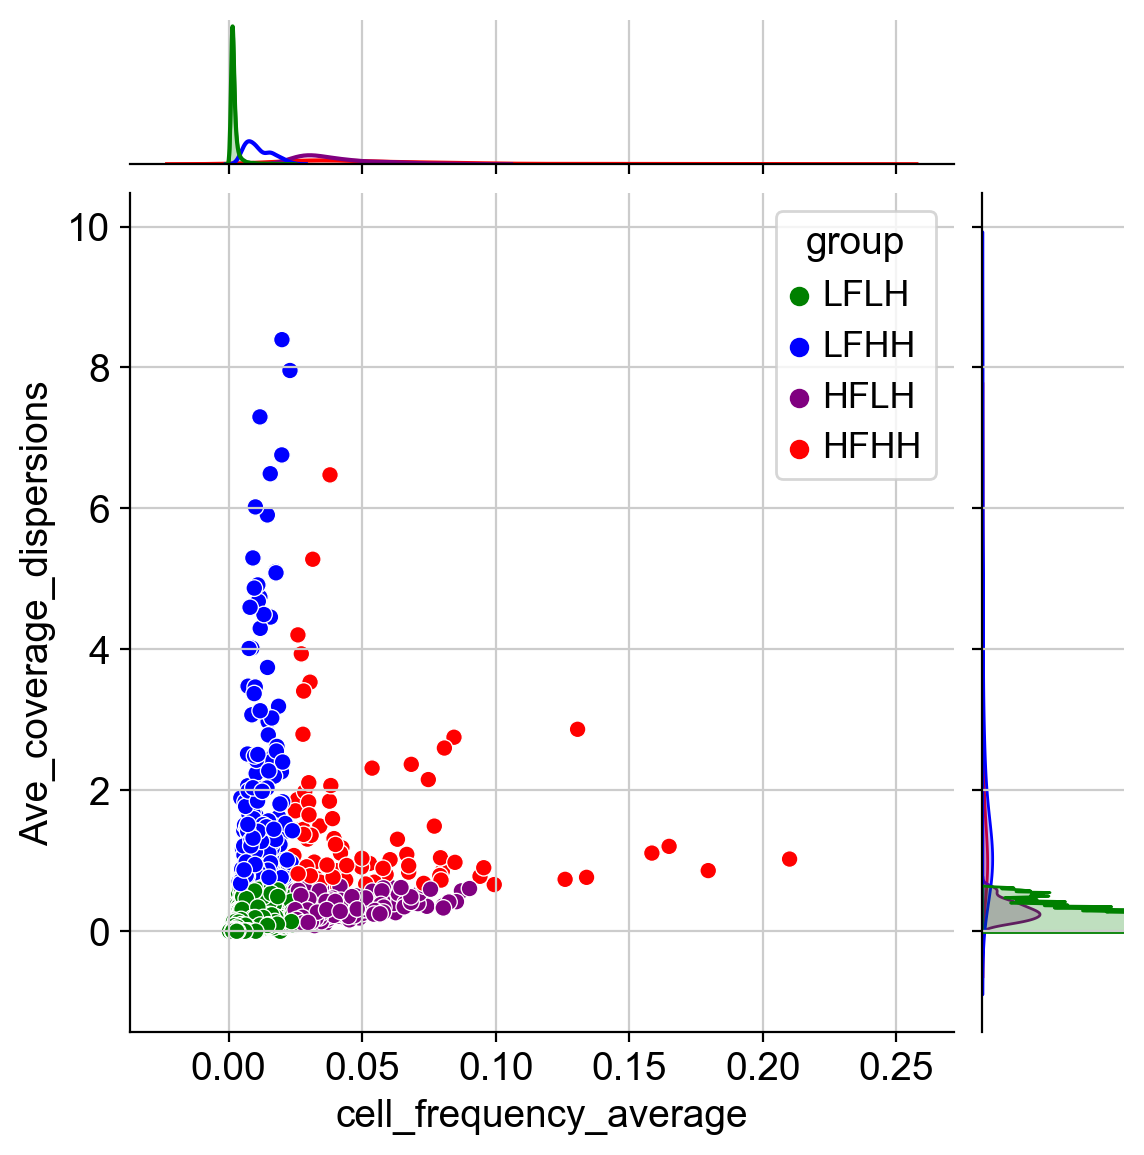

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 假设df_summary是您的DataFrame
#df_summary = pd.DataFrame()  # 示例，您需要用您的实际数据替换这里

# 定义列名
x_col = 'cell_frequency_average'
y_col = "Ave_coverage_dispersions"

# 计算最大值和bins
max_value = df_summary[x_col].max()
binwidth = (df_summary[x_col].max() - df_summary[x_col].min()) / 100
bins = np.arange(0, max_value + binwidth, binwidth)

# 定义颜色映射
color_mapping = {
    'HFHH': 'red',
    'HFLH': 'purple',
    'LFHH': 'blue',
    'LFLH': 'green'
}
x_cutoff = df_summary[x_col].quantile(0.99) # x_col列的上四分位数
y_cutoff = df_summary[y_col].quantile(0.99) # y_col列的上四分位数
# 根据cutoff值分组
def assign_group(row):
    if row[x_col] >= x_cutoff and row[y_col] >= y_cutoff:
        return 'HFHH'
    elif row[x_col] >= x_cutoff and row[y_col] < y_cutoff:
        return 'HFLH'
    elif row[x_col] < x_cutoff and row[y_col] >= y_cutoff:
        return 'LFHH'
    elif row[x_col] < x_cutoff and row[y_col] < y_cutoff:
        return 'LFLH'
# 应用分组函数
df_summary['group'] = df_summary.apply(assign_group, axis=1)

# 创建jointplot
g = sns.jointplot(data=df_summary, x=x_col, y=y_col, hue='group', palette=color_mapping, kind="scatter")
# 设置y轴的限制
plt.xlim(0, 0.05)
#plt.ylim(0, 1)
## 绘制核密度拟合曲线
for group in color_mapping:
    sns.kdeplot(data=df_summary[df_summary['group'] == group][x_col], ax=g.ax_marg_x, color=color_mapping[group], legend=False)
#    sns.kdeplot(data=df_summary[df_summary['group'] == group][y_col], ax=g.ax_marg_y, color=color_mapping[group], legend=False)
# 关闭网格线
#plt.grid(False)
# 添加图例
#plt.legend(title='Group', loc='upper right')
# 显示图表
#plt.show()
plt.savefig(f"./fig_100k_3/cell_frequency/f02-df_summary-{y_col}-scatterplot.pdf", bbox_inches='tight')

In [5]:
### 1739 common ecdna
#f"./fig_100k_3/cell_frequency_common/"

In [6]:
common_ecdna_tb = pd.read_csv("D:/02.project/18.ecDNA/02.code/v0.1.1/fig_100k/df_filled_ecdna_common_01.tsv",sep="\t",index_col=0)
common_ecdna_list = list(common_ecdna_tb.index)
common_ecdna_list
df_cancer_sample_cpr = pd.read_csv('./fig_100k_3/cell_frequency/f00-df_cancer_sample_cpr.xls', sep='\t')
df_cancer_sample_cpr_common = df_cancer_sample_cpr[df_cancer_sample_cpr["ecDNA_CPR"].isin(common_ecdna_list)]
df_cancer_sample_cpr_common
#df_cancer_sample_cpr_common.to_csv('./fig_100k_3/cell_frequency_common/f01-df_cancer_sample_cpr_common.xls', sep='\t', index=True)
len(df_cancer_sample_cpr_common["ecDNA_CPR"].unique())

1739

In [52]:
df_cancer_sample_cpr_common = pd.read_csv('./fig_100k_3/cell_frequency_common/f01-df_cancer_sample_cpr_common.xls', sep='\t', index_col=0)
len(df_cancer_sample_cpr_common["ecDNA_CPR"].unique())

1739

In [14]:
len(df_cancer_sample_cpr["ecDNA_CPR"].unique())

27691

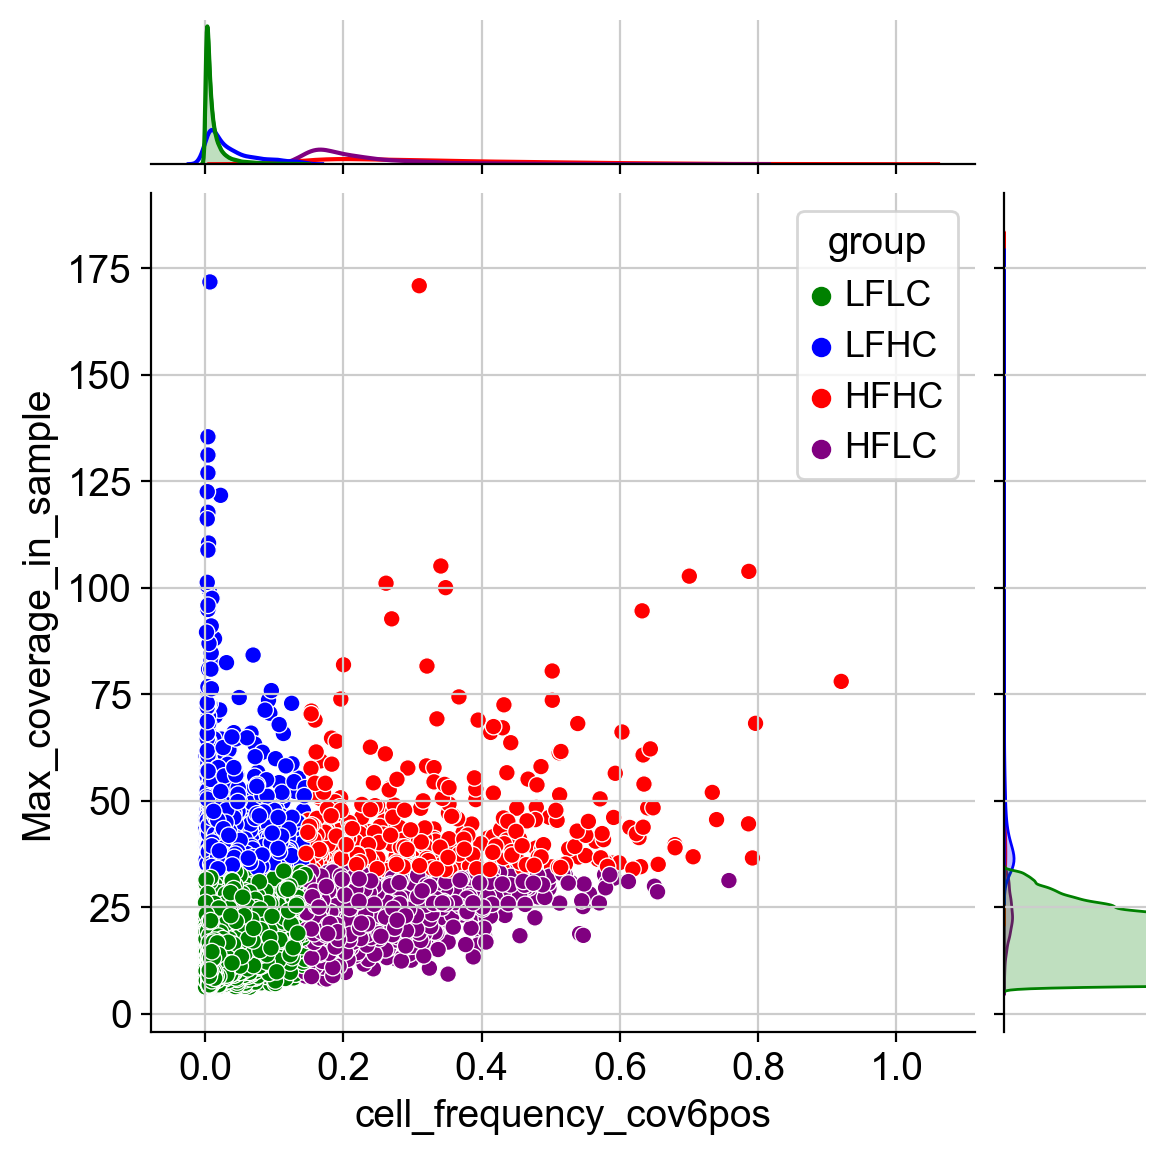

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 假设df_summary是您的DataFrame
#df_cancer_sample_cpr = pd.DataFrame()  # 示例，您需要用您的实际数据替换这里

# 定义列名
x_col = 'cell_frequency_cov6pos'
y_col = "Max_coverage_in_sample"

# 计算最大值和bins
max_value = df_cancer_sample_cpr_common[x_col].max()
binwidth = (df_cancer_sample_cpr_common[x_col].max() - df_cancer_sample_cpr_common[x_col].min()) / 100
bins = np.arange(0, max_value + binwidth, binwidth)

# 定义颜色映射
color_mapping = {
    'HFHC': 'red',
    'HFLC': 'purple',
    'LFHC': 'blue',
    'LFLC': 'green'
}
x_cutoff = df_cancer_sample_cpr_common[x_col].quantile(0.99) # x_col列的上四分位数
y_cutoff = df_cancer_sample_cpr_common[y_col].quantile(0.99) # y_col列的上四分位数
# 根据cutoff值分组
def assign_group(row):
    if row[x_col] >= x_cutoff and row[y_col] >= y_cutoff:
        return 'HFHC'
    elif row[x_col] >= x_cutoff and row[y_col] < y_cutoff:
        return 'HFLC'
    elif row[x_col] < x_cutoff and row[y_col] >= y_cutoff:
        return 'LFHC'
    elif row[x_col] < x_cutoff and row[y_col] < y_cutoff:
        return 'LFLC'
# 应用分组函数
df_cancer_sample_cpr_common['group'] = df_cancer_sample_cpr_common.apply(assign_group, axis=1)

# 创建jointplot
g = sns.jointplot(data=df_cancer_sample_cpr_common, x=x_col, y=y_col, hue='group', palette=color_mapping, kind="scatter")
# 设置y轴的限制
plt.xlim(0, 0.01)
#plt.ylim(0, 1)
## 绘制核密度拟合曲线
for group in color_mapping:
    sns.kdeplot(data=df_cancer_sample_cpr_common[df_cancer_sample_cpr_common['group'] == group][x_col], ax=g.ax_marg_x, color=color_mapping[group], legend=False)
#    sns.kdeplot(data=df_cancer_sample_cpr[df_cancer_sample_cpr['group'] == group][y_col], ax=g.ax_marg_y, color=color_mapping[group], legend=False)
# 关闭网格线
#plt.grid(False)
# 添加图例
#plt.legend(title='Group', loc='upper right')
# 显示图表
#plt.show()
plt.savefig(f"./fig_100k_3/cell_frequency_common/f02-df_summary-{y_col}-scatterplot.pdf", bbox_inches='tight')

In [75]:
import ast
df_chrom_unit = pd.read_csv(f'./fig_100k_3/chrom-unit/ecDNA_density_plots_ax-top_common.xls',sep="\t",index_col=0)
top_n = 25
# 从topn行中提取'ecDNA'列的值
topn_ecDNA_lists = df_chrom_unit.nlargest(top_n, 'counts')['ecDNA'].tolist()
# 最后，将这些列表合并为一个列表
merged_list = [item for sublist in topn_ecDNA_lists for item in ast.literal_eval(sublist)]
#merged_list

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
# 定义列名
x_col = 'cell_frequency_cov6pos'
y_col = "Max_coverage_in_sample"
# 定义颜色映射
color_mapping = {
    f'top_n={top_n}': 'red',
    'no_top_n': 'grey',
}
# 根据 isin merged_list 分组
def assign_group(row):
    if row["ecDNA_CPR"] in (merged_list):
        return f'top_n={top_n}'
    else:
        return 'no_top_n'
# 应用分组函数
df_cancer_sample_cpr_common['group'] = df_cancer_sample_cpr_common.apply(assign_group, axis=1)

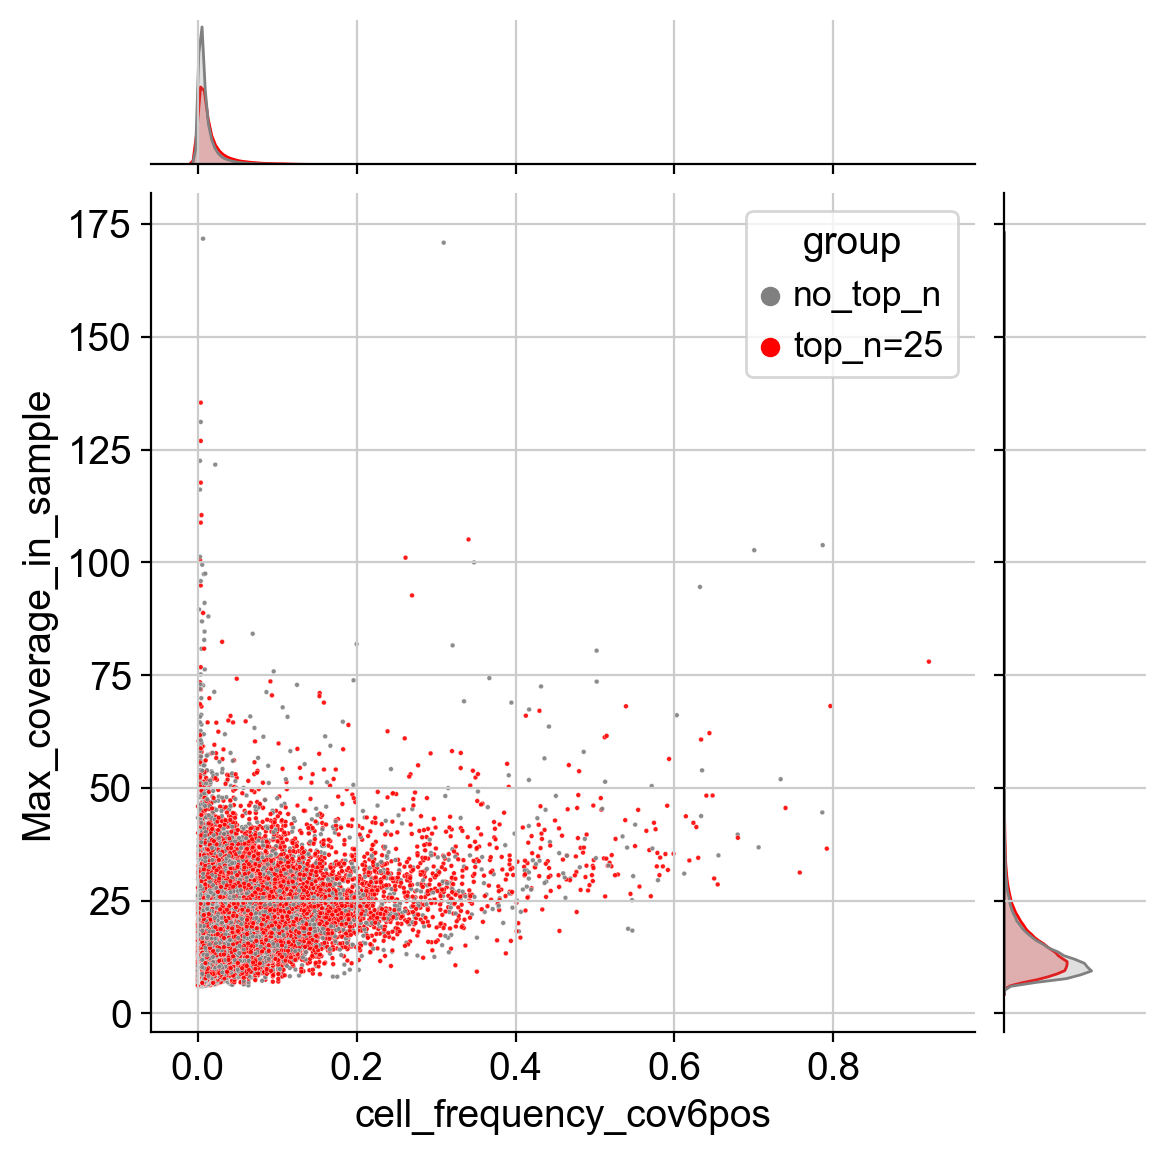

In [77]:
# 创建jointplot
g = sns.jointplot(data=df_cancer_sample_cpr_common, x=x_col, y=y_col, hue='group', palette=color_mapping, kind="scatter",s=3,alpha=0.9)
# 设置y轴的限制
plt.xlim(0, 0.1)
#plt.ylim(0, 1)
## 绘制核密度拟合曲线
#for group in color_mapping:
#    sns.kdeplot(data=df_cancer_sample_cpr_common[df_cancer_sample_cpr_common['group'] == group][x_col], ax=g.ax_marg_x, color=color_mapping[group], legend=False)
#    sns.kdeplot(data=df_cancer_sample_cpr[df_cancer_sample_cpr['group'] == group][y_col], ax=g.ax_marg_y, color=color_mapping[group], legend=False)
# 关闭网格线
plt.savefig(f"./fig_100k_3/cell_frequency_common/f02-df_summary-{y_col}-scatterplot-top_{top_n}.pdf", bbox_inches='tight')

In [8]:
df_cancer_sample_cpr_common

,cancer,sample,ecDNA_CPR,cell_number_cov6pos,cell_frequency_cov6pos,Ave_coverage_in_sample,Max_coverage_in_sample,Median_coverage_in_sample,chr_100k,n_cells
8,BRCA,ht029b1-s1pc,chr10:101000000_101100000,17,0.004632,0.042093,16.932271,0.0,chr10:101000000_101100000,17.0
16,BRCA,ht029b1-s1pc,chr10:102100000_102200000,18,0.004905,0.040838,12.734219,0.0,chr10:102100000_102200000,18.0
19,BRCA,ht029b1-s1pc,chr10:102400000_102500000,25,0.006812,0.060130,12.936146,0.0,chr10:102400000_102500000,25.0
21,BRCA,ht029b1-s1pc,chr10:102600000_102700000,29,0.007902,0.059315,10.698366,0.0,chr10:102600000_102700000,29.0
22,BRCA,ht029b1-s1pc,chr10:102700000_102800000,16,0.004360,0.034791,11.082379,0.0,chr10:102700000_102800000,16.0
...,...,...,...,...,...,...,...,...,...,...
765029,UCEC,cpt704du-t1,chr9:35700000_35800000,4,0.007767,0.060106,10.030090,0.0,chr9:35700000_35800000,4.0
765037,UCEC,cpt704du-t1,chrX:153700000_153800000,3,0.005825,0.043214,8.774563,0.0,chrX:153700000_153800000,3.0
765038,UCEC,cpt704du-t1,chrX:153900000_154000000,6,0.011650,0.101160,13.002601,0.0,chrX:153900000_154000000,6.0
765039,UCEC,cpt704du-t1,chrX:154300000_154400000,3,0.005825,0.050279,10.220470,0.0,chrX:154300000_154400000,3.0


In [ ]:
### 分组计算cell frequency std

In [101]:
# 根据'col1'列的值进行分组，并计算每组'col2'列的平均值
cell_frequency_average = df_cancer_sample_cpr_common.groupby('ecDNA_CPR')['cell_frequency_cov6pos'].mean()
cell_frequency_median = df_cancer_sample_cpr_common.groupby('ecDNA_CPR')['cell_frequency_cov6pos'].median()
cell_frequency_std = df_cancer_sample_cpr_common.groupby('ecDNA_CPR')['cell_frequency_cov6pos'].std()
grouped = df_cancer_sample_cpr_common.groupby('ecDNA_CPR')['cell_frequency_cov6pos'].agg(['mean', 'var']) # 分组计算平均值和方差
cell_frequency_dispersions = grouped['var'] / grouped['mean'] # 计算散度
# 根据'col1'列的值进行分组，并计算每组'col2'列的标准差
Ave_coverage_std = df_cancer_sample_cpr_common.groupby('ecDNA_CPR')['Ave_coverage_in_sample'].std()
Median_coverage_std = df_cancer_sample_cpr_common.groupby('ecDNA_CPR')['Median_coverage_in_sample'].std()
grouped = df_cancer_sample_cpr_common.groupby('ecDNA_CPR')['Ave_coverage_in_sample'].agg(['mean', 'var']) # 分组计算平均值和方差
Ave_coverage_dispersions = grouped['var'] / grouped['mean'] # 计算散度
grouped = df_cancer_sample_cpr_common.groupby('ecDNA_CPR')['Median_coverage_in_sample'].agg(['mean', 'var']) # 分组计算平均值和方差
Median_coveragee_dispersions = grouped['var'] / grouped['mean'] # 计算散度

# 创建一个新的DataFrame，包含计算得到的平均值和中位数
df_summary_common = pd.DataFrame({
    'cell_frequency_average': cell_frequency_average,
    'cell_frequency_median': cell_frequency_median,
    'cell_frequency_std': cell_frequency_std,
    'cell_frequency_dispersions': cell_frequency_dispersions,
    'Ave_coverage_std': Ave_coverage_std,
    'Median_coverage_std': Median_coverage_std,
    'Ave_coverage_dispersions': Ave_coverage_dispersions,
    'Median_coveragee_dispersions': Median_coveragee_dispersions
})
df_summary_common = df_summary_common.fillna(0)
df_summary_common.to_csv('./fig_100k_3/cell_frequency_common/f01-df_cancer_sample_cpr_common-df_summary_common.xls', sep='\t', index=True)
df_summary_common

,cell_frequency_average,cell_frequency_median,cell_frequency_std,cell_frequency_dispersions,Ave_coverage_std,Median_coverage_std,Ave_coverage_dispersions,Median_coveragee_dispersions
ecDNA_CPR,,,,,,,,
chr10:101000000_101100000,0.021500,0.017467,0.017583,0.014379,0.143002,0.0,0.120145,0.0
chr10:102100000_102200000,0.010379,0.009299,0.007449,0.005346,0.058437,0.0,0.042774,0.0
chr10:102400000_102500000,0.016016,0.014050,0.012045,0.009058,0.094127,0.0,0.070700,0.0
chr10:102600000_102700000,0.016278,0.013141,0.012248,0.009216,0.098743,0.0,0.076160,0.0
chr10:102700000_102800000,0.007175,0.004545,0.007644,0.008144,0.059924,0.0,0.064804,0.0
...,...,...,...,...,...,...,...,...
chrX:153700000_153800000,0.014915,0.010870,0.012892,0.011143,0.103328,0.0,0.090163,0.0
chrX:153900000_154000000,0.023539,0.017776,0.020439,0.017747,0.159501,0.0,0.136941,0.0
chrX:154300000_154400000,0.009752,0.007128,0.007630,0.005970,0.058413,0.0,0.045882,0.0


In [53]:
df_summary_common = pd.read_csv('./fig_100k_3/cell_frequency_common/f01-df_cancer_sample_cpr_common-df_summary_common.xls', sep='\t', index_col=0)
df_summary_common
df_summary = df_summary_common.copy()

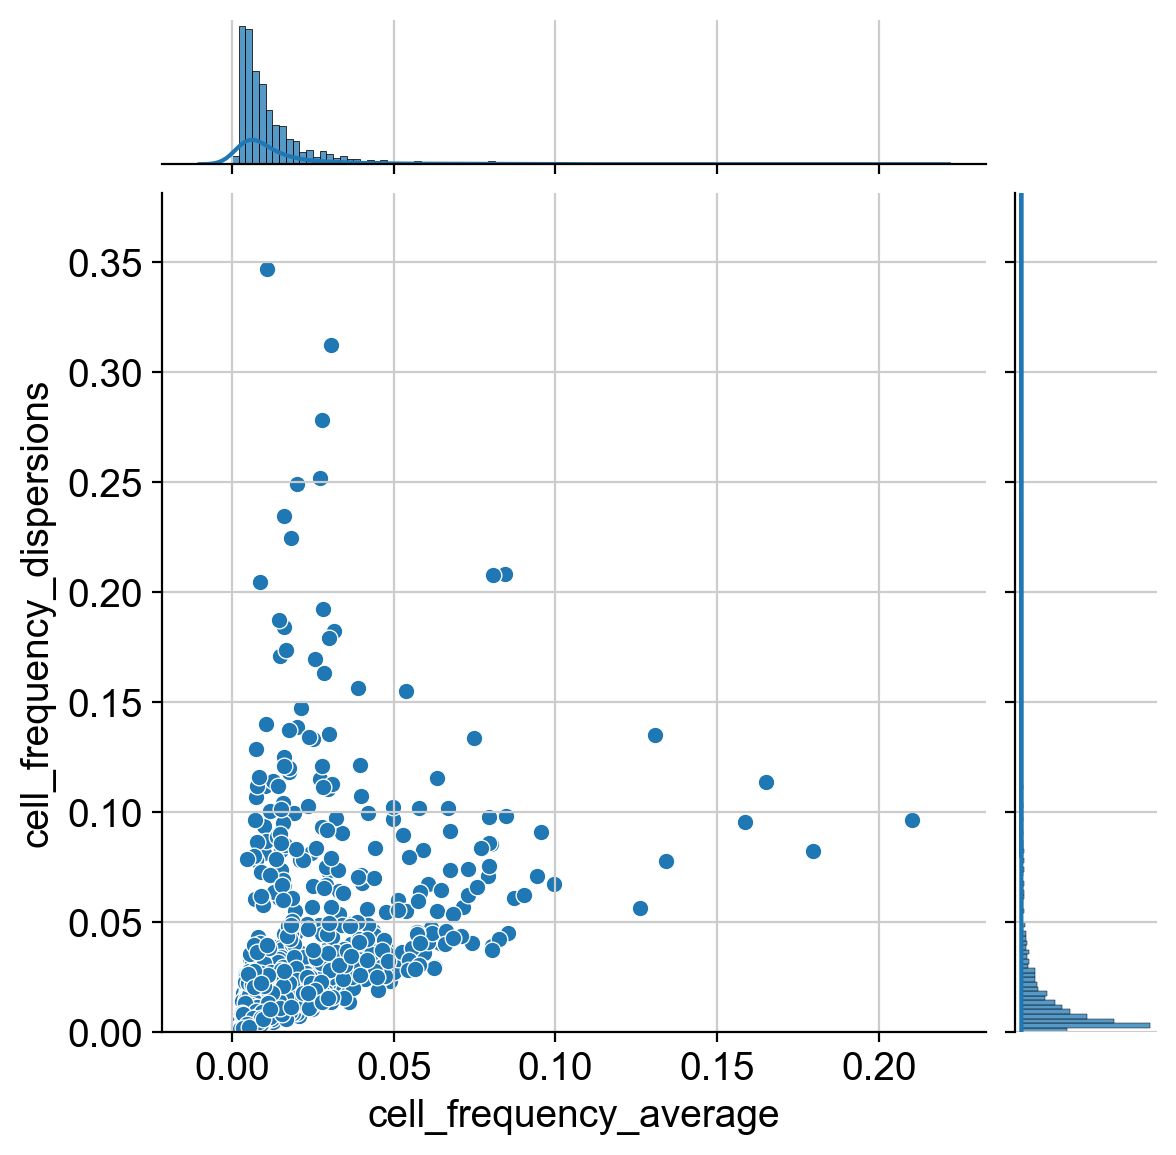

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 假设df是您的DataFrame，'x_col'和'y_col'是您想要作为坐标轴的列名
x_col = 'cell_frequency_average'
y_col = "cell_frequency_dispersions"

max_value = df_summary[x_col].max()
binwidth=(df_summary[x_col].max()-df_summary[x_col].min())/100
bins = np.arange(0, max_value + binwidth, binwidth)

# 创建一个jointplot，绘制散点图和核密度拟合曲线
g = sns.jointplot(data=df_summary, x=x_col, y=y_col, kind="scatter", marginal_kws=dict(bins=bins, fill=True))
plt.ylim(0, df_summary[y_col].max()*1.1)
# 绘制x轴和y轴的核密度拟合曲线
sns.kdeplot(data=df_summary[x_col], ax=g.ax_marg_x, vertical=True, legend=False)
sns.kdeplot(data=df_summary[y_col], ax=g.ax_marg_y, vertical=True, legend=False)
#plt.grid(False)  # 关闭网格线
# 显示图表
#plt.show()
plt.savefig(f"./fig_100k_3/cell_frequency_common/f01-df_summary-{y_col}-scatterplot.pdf", bbox_inches='tight')

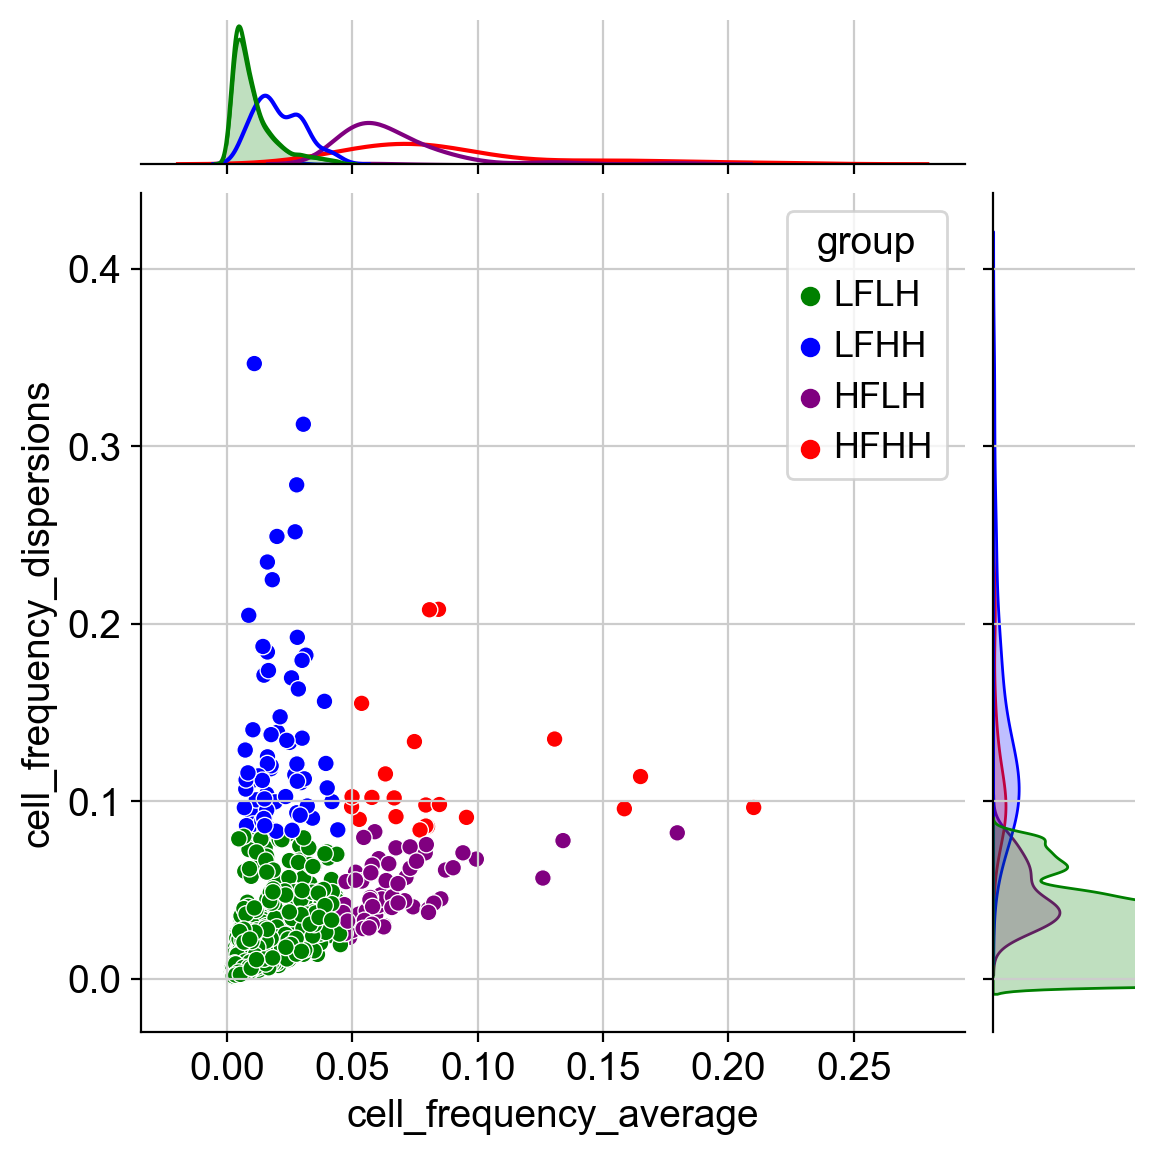

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 假设df_summary是您的DataFrame
#df_summary = pd.DataFrame()  # 示例，您需要用您的实际数据替换这里

# 定义列名
x_col = 'cell_frequency_average'
y_col = "cell_frequency_dispersions"

# 计算最大值和bins
max_value = df_summary[x_col].max()
binwidth = (df_summary[x_col].max() - df_summary[x_col].min()) / 100
bins = np.arange(0, max_value + binwidth, binwidth)

# 定义颜色映射
color_mapping = {
    'HFHH': 'red',
    'HFLH': 'purple',
    'LFHH': 'blue',
    'LFLH': 'green'
}
x_cutoff = df_summary[x_col].quantile(0.95) # x_col列的上四分位数
y_cutoff = df_summary[y_col].quantile(0.95) # y_col列的上四分位数
# 根据cutoff值分组
def assign_group(row):
    if row[x_col] >= x_cutoff and row[y_col] >= y_cutoff:
        return 'HFHH'
    elif row[x_col] >= x_cutoff and row[y_col] < y_cutoff:
        return 'HFLH'
    elif row[x_col] < x_cutoff and row[y_col] >= y_cutoff:
        return 'LFHH'
    elif row[x_col] < x_cutoff and row[y_col] < y_cutoff:
        return 'LFLH'
# 应用分组函数
df_summary['group'] = df_summary.apply(assign_group, axis=1)

# 创建jointplot
g = sns.jointplot(data=df_summary, x=x_col, y=y_col, hue='group', palette=color_mapping, kind="scatter")
#g = sns.scatterplot(data=df_summary, x=x_col, y=y_col, hue='group', palette=color_mapping)
# 设置y轴的限制
plt.xlim(0, 2)
#plt.ylim(-0.05, 0.4)
## 绘制核密度拟合曲线
for group in color_mapping:
    sns.kdeplot(data=df_summary[df_summary['group'] == group][x_col], ax=g.ax_marg_x, color=color_mapping[group], legend=False)
    #sns.kdeplot(data=df_summary[df_summary['group'] == group][y_col], ax=g.ax_marg_y, color=color_mapping[group], legend=False)
# 关闭网格线
#plt.grid(False)
# 添加图例
#plt.legend(title='Group', loc='upper right')
# 显示图表
#plt.show()
plt.savefig(f"./fig_100k_3/cell_frequency_common/f02-df_summary-{y_col}-scatterplot_095_095_s.pdf", bbox_inches='tight')

df_summary.to_csv('./fig_100k_3/cell_frequency_common/f01-df_cancer_sample_cpr_common-df_summary_common_4group_095_095_s.xls', sep='\t', index=True)

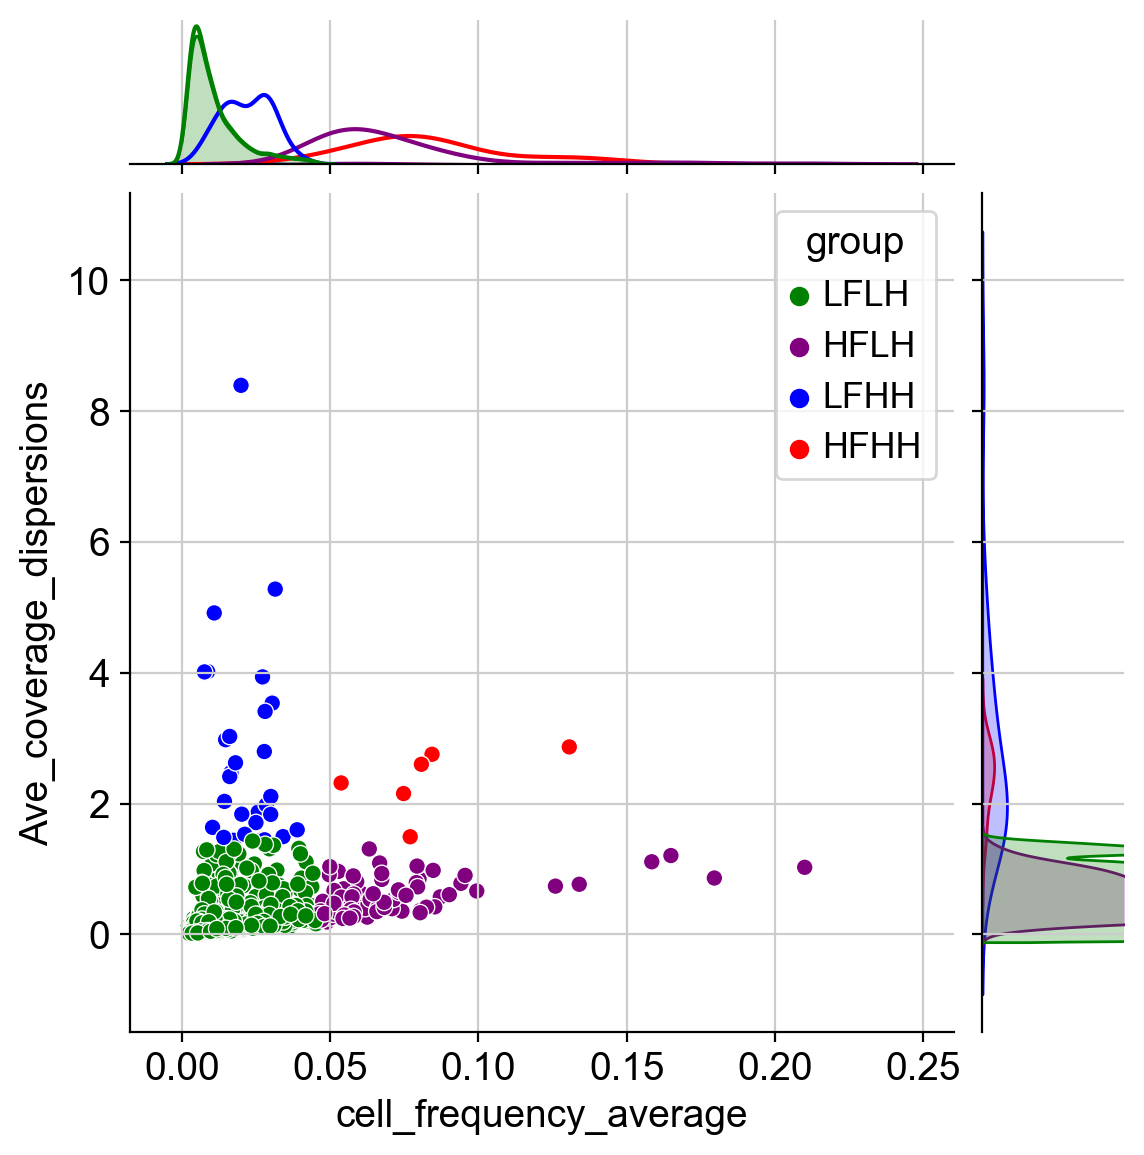

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 假设df_summary是您的DataFrame
#df_summary = pd.DataFrame()  # 示例，您需要用您的实际数据替换这里
# 定义列名
x_col = 'cell_frequency_average'
y_col = "Ave_coverage_dispersions"
# 计算最大值和bins
max_value = df_summary[x_col].max()
binwidth = (df_summary[x_col].max() - df_summary[x_col].min()) / 100
bins = np.arange(0, max_value + binwidth, binwidth)
# 定义颜色映射
color_mapping = {
    'HFHH': 'red',
    'HFLH': 'purple',
    'LFHH': 'blue',
    'LFLH': 'green'
}
x_cutoff = df_summary[x_col].quantile(0.95) # x_col列的上四分位数
y_cutoff = df_summary[y_col].quantile(0.98) # y_col列的上四分位数
# 根据cutoff值分组
def assign_group(row):
    if row[x_col] >= x_cutoff and row[y_col] >= y_cutoff:
        return 'HFHH'
    elif row[x_col] >= x_cutoff and row[y_col] < y_cutoff:
        return 'HFLH'
    elif row[x_col] < x_cutoff and row[y_col] >= y_cutoff:
        return 'LFHH'
    elif row[x_col] < x_cutoff and row[y_col] < y_cutoff:
        return 'LFLH'
# 应用分组函数
df_summary['group'] = df_summary.apply(assign_group, axis=1)

# 创建jointplot
g = sns.jointplot(data=df_summary, x=x_col, y=y_col, hue='group', palette=color_mapping, kind="scatter")
# 设置y轴的限制
plt.xlim(0, 0.03)
#plt.ylim(0, 1)
## 绘制核密度拟合曲线
for group in color_mapping:
    sns.kdeplot(data=df_summary[df_summary['group'] == group][x_col], ax=g.ax_marg_x, color=color_mapping[group], legend=False)
#    sns.kdeplot(data=df_summary[df_summary['group'] == group][y_col], ax=g.ax_marg_y, color=color_mapping[group], legend=False)
# 关闭网格线
#plt.grid(False)
# 添加图例
#plt.legend(title='Group', loc='upper right')
# 显示图表
#plt.show()
plt.savefig(f"./fig_100k_3/cell_frequency_common/f02-df_summary-{y_col}-scatterplot.pdf", bbox_inches='tight')

In [ ]:
#上四分位数

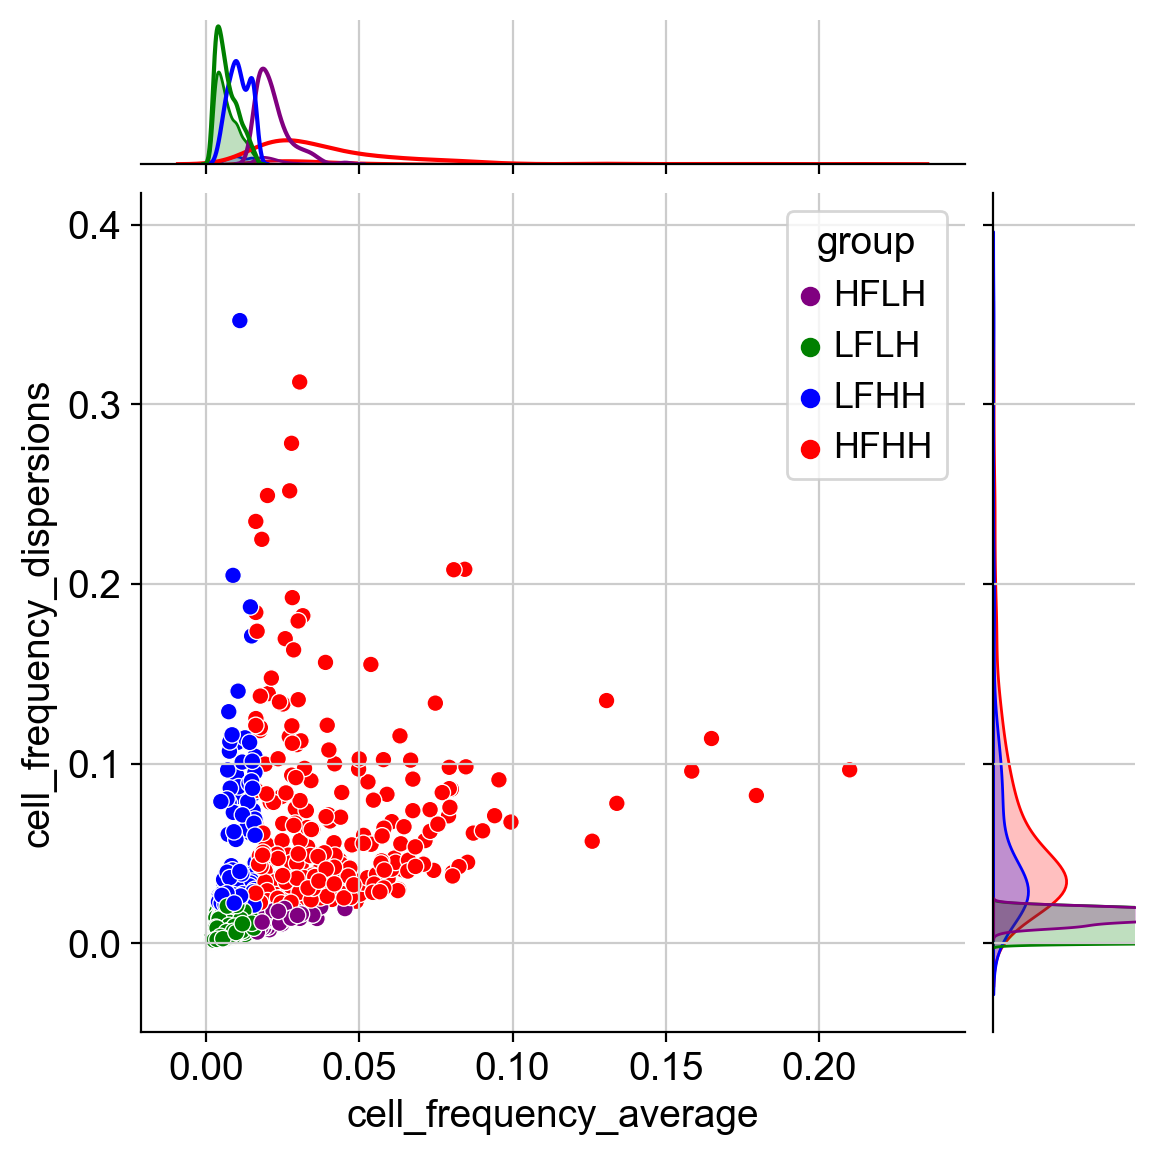

In [126]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 假设df_summary是您的DataFrame
#df_summary = pd.DataFrame()  # 示例，您需要用您的实际数据替换这里

# 定义列名
x_col = 'cell_frequency_average'
y_col = "cell_frequency_dispersions"

# 计算最大值和bins
max_value = df_summary[x_col].max()
binwidth = (df_summary[x_col].max() - df_summary[x_col].min()) / 100
bins = np.arange(0, max_value + binwidth, binwidth)

# 定义颜色映射
color_mapping = {
    'HFHH': 'red',
    'HFLH': 'purple',
    'LFHH': 'blue',
    'LFLH': 'green'
}
top_cutoff = 0.25
x_cutoff = df_summary[x_col].quantile(1-top_cutoff) # x_col列的上四分位数
y_cutoff = df_summary[y_col].quantile(1-top_cutoff) # y_col列的上四分位数
# 根据cutoff值分组
def assign_group(row):
    if row[x_col] >= x_cutoff and row[y_col] >= y_cutoff:
        return 'HFHH'
    elif row[x_col] >= x_cutoff and row[y_col] < y_cutoff:
        return 'HFLH'
    elif row[x_col] < x_cutoff and row[y_col] >= y_cutoff:
        return 'LFHH'
    elif row[x_col] < x_cutoff and row[y_col] < y_cutoff:
        return 'LFLH'
# 应用分组函数
df_summary['group'] = df_summary.apply(assign_group, axis=1)

# 创建jointplot
g = sns.jointplot(data=df_summary, x=x_col, y=y_col, hue='group', palette=color_mapping, kind="scatter")
# 设置y轴的限制
plt.xlim(0, 5)
#plt.ylim(-0.05, 0.4)
## 绘制核密度拟合曲线
for group in color_mapping:
    sns.kdeplot(data=df_summary[df_summary['group'] == group][x_col], ax=g.ax_marg_x, color=color_mapping[group], legend=False)
#    sns.kdeplot(data=df_summary[df_summary['group'] == group][y_col], ax=g.ax_marg_y, color=color_mapping[group], legend=False)
# 关闭网格线
#plt.grid(False)
# 添加图例
#plt.legend(title='Group', loc='upper right')
# 显示图表
#plt.show()
plt.savefig(f"./fig_100k_3/cell_frequency_common/f03-df_summary-{y_col}-scatterplot-top025.pdf", bbox_inches='tight')

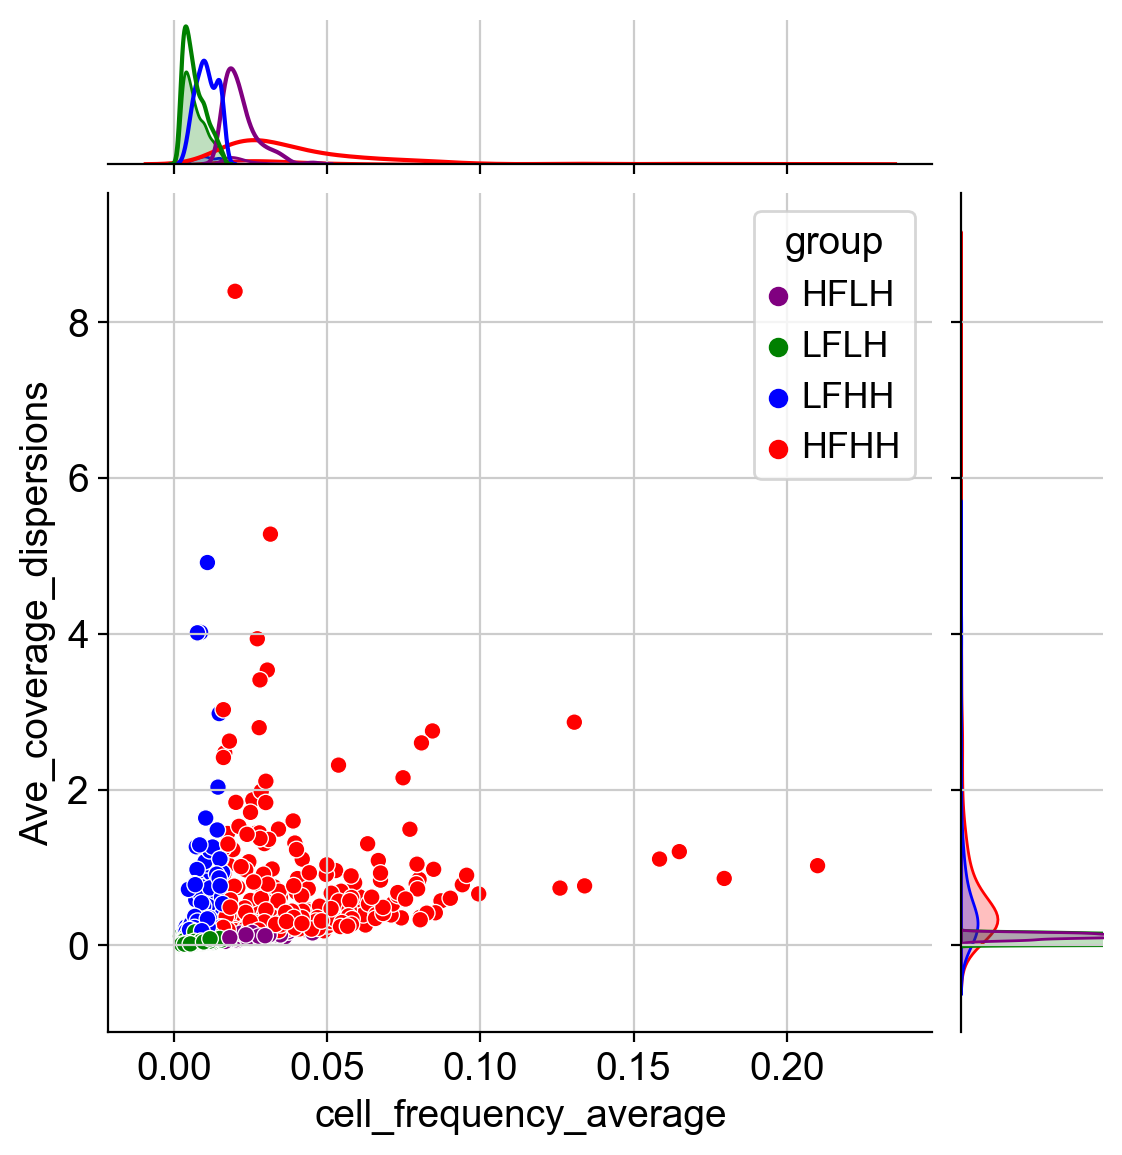

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 假设df_summary是您的DataFrame
#df_summary = pd.DataFrame()  # 示例，您需要用您的实际数据替换这里

# 定义列名
x_col = 'cell_frequency_average'
y_col = "Ave_coverage_dispersions"

# 计算最大值和bins
max_value = df_summary[x_col].max()
binwidth = (df_summary[x_col].max() - df_summary[x_col].min()) / 100
bins = np.arange(0, max_value + binwidth, binwidth)

# 定义颜色映射
color_mapping = {
    'HFHH': 'red',
    'HFLH': 'purple',
    'LFHH': 'blue',
    'LFLH': 'green'
}
top_cutoff = 0.25
x_cutoff = df_summary[x_col].quantile(1-top_cutoff) # x_col列的上四分位数
y_cutoff = df_summary[y_col].quantile(1-top_cutoff) # y_col列的上四分位数
# 根据cutoff值分组
def assign_group(row):
    if row[x_col] >= x_cutoff and row[y_col] >= y_cutoff:
        return 'HFHH'
    elif row[x_col] >= x_cutoff and row[y_col] < y_cutoff:
        return 'HFLH'
    elif row[x_col] < x_cutoff and row[y_col] >= y_cutoff:
        return 'LFHH'
    elif row[x_col] < x_cutoff and row[y_col] < y_cutoff:
        return 'LFLH'
# 应用分组函数
df_summary['group'] = df_summary.apply(assign_group, axis=1)

# 创建jointplot
g = sns.jointplot(data=df_summary, x=x_col, y=y_col, hue='group', palette=color_mapping, kind="scatter")
# 设置y轴的限制
plt.xlim(0, 0.7)
#plt.ylim(0, 1)
## 绘制核密度拟合曲线
for group in color_mapping:
    sns.kdeplot(data=df_summary[df_summary['group'] == group][x_col], ax=g.ax_marg_x, color=color_mapping[group], legend=False)
#    sns.kdeplot(data=df_summary[df_summary['group'] == group][y_col], ax=g.ax_marg_y, color=color_mapping[group], legend=False)
# 关闭网格线
#plt.grid(False)
# 添加图例
#plt.legend(title='Group', loc='upper right')
# 显示图表
#plt.show()
plt.savefig(f"./fig_100k_3/cell_frequency_common/f03-df_summary-{y_col}-scatterplot-top025.pdf", bbox_inches='tight')

In [ ]:
### cell frequency heatmap

In [117]:
df_summary = pd.read_csv('./fig_100k_3/cell_frequency_common/f01-df_cancer_sample_cpr_common-df_summary_common_4group_095_095_s.xls', sep='\t', index_col=0)
df_summary["ecDNA_CPR"] = df_summary.index
df_summary

,cell_frequency_average,cell_frequency_median,cell_frequency_std,cell_frequency_dispersions,Ave_coverage_std,Median_coverage_std,Ave_coverage_dispersions,Median_coveragee_dispersions,group,ecDNA_CPR
ecDNA_CPR,,,,,,,,,,
chr10:101000000_101100000,0.021500,0.017467,0.017583,0.014379,0.143002,0.0,0.120145,0.0,LFLH,chr10:101000000_101100000
chr10:102100000_102200000,0.010379,0.009299,0.007449,0.005346,0.058437,0.0,0.042774,0.0,LFLH,chr10:102100000_102200000
chr10:102400000_102500000,0.016016,0.014050,0.012045,0.009058,0.094127,0.0,0.070700,0.0,LFLH,chr10:102400000_102500000
chr10:102600000_102700000,0.016278,0.013141,0.012248,0.009216,0.098743,0.0,0.076160,0.0,LFLH,chr10:102600000_102700000
chr10:102700000_102800000,0.007175,0.004545,0.007644,0.008144,0.059924,0.0,0.064804,0.0,LFLH,chr10:102700000_102800000
...,...,...,...,...,...,...,...,...,...,...
chrX:153700000_153800000,0.014915,0.010870,0.012892,0.011143,0.103328,0.0,0.090163,0.0,LFLH,chrX:153700000_153800000
chrX:153900000_154000000,0.023539,0.017776,0.020439,0.017747,0.159501,0.0,0.136941,0.0,LFLH,chrX:153900000_154000000
chrX:154300000_154400000,0.009752,0.007128,0.007630,0.005970,0.058413,0.0,0.045882,0.0,LFLH,chrX:154300000_154400000


In [118]:
df_cancer_sample_cpr_common = pd.read_csv('./fig_100k_3/cell_frequency_common/f01-df_cancer_sample_cpr_common.xls', sep='\t', index_col=0)
print(len(df_cancer_sample_cpr_common["ecDNA_CPR"].unique()))
df_cancer_sample_cpr_common

1739


,cancer,sample,ecDNA_CPR,cell_number_cov6pos,cell_frequency_cov6pos,Ave_coverage_in_sample,Max_coverage_in_sample,Median_coverage_in_sample,chr_100k,n_cells
8,BRCA,ht029b1-s1pc,chr10:101000000_101100000,17,0.004632,0.042093,16.932271,0.0,chr10:101000000_101100000,17.0
16,BRCA,ht029b1-s1pc,chr10:102100000_102200000,18,0.004905,0.040838,12.734219,0.0,chr10:102100000_102200000,18.0
19,BRCA,ht029b1-s1pc,chr10:102400000_102500000,25,0.006812,0.060130,12.936146,0.0,chr10:102400000_102500000,25.0
21,BRCA,ht029b1-s1pc,chr10:102600000_102700000,29,0.007902,0.059315,10.698366,0.0,chr10:102600000_102700000,29.0
22,BRCA,ht029b1-s1pc,chr10:102700000_102800000,16,0.004360,0.034791,11.082379,0.0,chr10:102700000_102800000,16.0
...,...,...,...,...,...,...,...,...,...,...
765029,UCEC,cpt704du-t1,chr9:35700000_35800000,4,0.007767,0.060106,10.030090,0.0,chr9:35700000_35800000,4.0
765037,UCEC,cpt704du-t1,chrX:153700000_153800000,3,0.005825,0.043214,8.774563,0.0,chrX:153700000_153800000,3.0
765038,UCEC,cpt704du-t1,chrX:153900000_154000000,6,0.011650,0.101160,13.002601,0.0,chrX:153900000_154000000,6.0
765039,UCEC,cpt704du-t1,chrX:154300000_154400000,3,0.005825,0.050279,10.220470,0.0,chrX:154300000_154400000,3.0


In [119]:
# 使用pivot函数根据col1和col2的值重塑数据，col3作为新的元素值
df_mtx = df_cancer_sample_cpr_common.pivot(index='ecDNA_CPR', columns='sample', values='cell_frequency_cov6pos')
df_mtx = df_mtx.fillna(0)
df_mtx

sample,ce321,ce327-c1a2,ce332e1-n1,ce334,ce336e1-s1,ce337e1-s1,ce338e1-s1,ce339e1-s1,ce340e1-s1,ce342e1-s1,...,vf029v1-s1,vf031v1-tm1,vf032v1-s1,vf034v1-t1,vf035v1-s1,vf044v1-s1,vf050v1-s2,wu044,wu082,wu090
ecDNA_CPR,,,,,,,,,,,,,,,,,,,,,
chr10:101000000_101100000,0.024490,0.000000,0.041209,0.020192,0.022962,0.019498,0.006435,0.027668,0.022490,0.016291,...,0.015789,0.023607,0.020085,0.003033,0.011962,0.037516,0.008731,0.000000,0.008824,0.010577
chr10:102100000_102200000,0.015306,0.000000,0.019231,0.012500,0.005155,0.010652,0.004251,0.017128,0.013253,0.010182,...,0.015789,0.014706,0.002564,0.004044,0.010538,0.014089,0.009701,0.000000,0.000000,0.005769
chr10:102400000_102500000,0.024490,0.007653,0.010989,0.012500,0.012184,0.015887,0.006435,0.031621,0.023494,0.018582,...,0.021053,0.025929,0.045299,0.008426,0.013671,0.031946,0.013000,0.000000,0.011765,0.003846
chr10:102600000_102700000,0.025510,0.000000,0.013736,0.011538,0.007498,0.016248,0.004826,0.013175,0.015060,0.029019,...,0.000000,0.031347,0.014530,0.006404,0.011678,0.032929,0.018820,0.000000,0.000000,0.016346
chr10:102700000_102800000,0.004082,0.000000,0.000000,0.004808,0.001874,0.008305,0.001379,0.011858,0.003815,0.004709,...,0.000000,0.013932,0.002991,0.002696,0.007975,0.010813,0.003104,0.000000,0.000000,0.005769
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
chrX:153700000_153800000,0.014286,0.000000,0.008242,0.045192,0.012184,0.009027,0.033781,0.030303,0.051606,0.022655,...,0.000000,0.013545,0.005556,0.007752,0.021077,0.011959,0.020955,0.000000,0.011765,0.000000
chrX:153900000_154000000,0.035714,0.010204,0.010989,0.032692,0.011715,0.023470,0.027232,0.017128,0.065060,0.024437,...,0.000000,0.024381,0.007479,0.032019,0.057249,0.023755,0.046566,0.015209,0.000000,0.004808
chrX:154300000_154400000,0.005102,0.000000,0.000000,0.025000,0.002812,0.003611,0.015857,0.013175,0.023293,0.014637,...,0.000000,0.011610,0.001496,0.007078,0.028767,0.013270,0.021537,0.000000,0.000000,0.002885


In [120]:
# get dir_cancer_sample / dir_group_ecDNACPR 的顺序
dir_cancer_sample = df_cancer_sample_cpr_common[["cancer","sample"]].drop_duplicates(["cancer","sample"]).sort_values(by=["cancer","sample"])
dir_cancer_sample.set_index(['sample'], inplace=True)
dir_cancer_sample["sample"] = dir_cancer_sample.index
dir_group_ecDNACPR = df_summary[["group"]].sort_values(by=["group"])
dir_group_ecDNACPR["ecDNA_CPR"] = dir_group_ecDNACPR.index

# 将 df_mtx 的columns/index 的顺序重新排列为 dir_cancer_sample / dir_group_ecDNACPR 的顺序
df_mtx = df_mtx.reindex(columns=dir_cancer_sample.index)
df_mtx = df_mtx.reindex(index=dir_group_ecDNACPR.index)

# 使用df2创建一个多重索引 # 将df1的列更新为多重索引
multi_columns = pd.MultiIndex.from_frame(dir_cancer_sample[['cancer', 'sample']])
df_mtx.columns = multi_columns
multi_index = pd.MultiIndex.from_frame(dir_group_ecDNACPR[['group', 'ecDNA_CPR']])
df_mtx.index = multi_index
df_mtx

cancer                                BRCA                            \
sample                        ht029b1-s1pc ht035b1-s1pa ht088b1-s1h1   
group ecDNA_CPR                                                        
HFHH  chr20:62600000_62700000     0.002725     0.005654     0.014226   
      chr19:45400000_45500000     0.238965     0.067447     0.086829   
      chr19:44700000_44800000     0.187738     0.035137     0.055678   
      chr22:46000000_46100000     0.023706     0.185784     0.031641   
      chr19:42200000_42300000     0.039782     0.154685     0.104979   
...                                    ...          ...          ...   
LFLH  chr17:73500000_73600000     0.003270     0.002827     0.000000   
      chr17:73300000_73400000     0.098638     0.031099     0.002943   
      chr17:7300000_7400000       0.019619     0.023425     0.006623   
      chr17:75000000_75100000     0.076839     0.023425     0.006868   
      chrX:300000_400000          0.002725     0.002019     0.009075   

cancer                                                                \
sample                        ht088b1-s1h2 ht128b1-s1h4 ht137b1-s1h7   
group ecDNA_CPR                                                        
HFHH  chr20:62600000_62700000     0.010228     0.005420     0.015591   
      chr19:45400000_45500000     0.047172     0.022455     0.062908   
      chr19:44700000_44800000     0.034022     0.014324     0.024474   
      chr22:46000000_46100000     0.011689     0.034069     0.048042   
      chr19:42200000_42300000     0.061991     0.020906     0.082850   
...                                    ...          ...          ...   
LFLH  chr17:73500000_73600000     0.000000     0.001549     0.008521   
      chr17:73300000_73400000     0.000626     0.004646     0.017585   
      chr17:7300000_7400000       0.002087     0.005807     0.027194   
      chr17:75000000_75100000     0.004174     0.008517     0.017223   
      chrX:300000_400000          0.007514     0.011227     0.012690   

cancer                                                             \
sample                        ht1408-06 ht141b1-s1h1 ht206b1-s1h4   
group ecDNA_CPR                                                     
HFHH  chr20:62600000_62700000  0.016301     0.009091     0.000000   
      chr19:45400000_45500000  0.018495     0.044385     0.481928   
      chr19:44700000_44800000  0.006583     0.010695     0.134251   
      chr22:46000000_46100000  0.026019     0.180214     0.017212   
      chr19:42200000_42300000  0.025549     0.078075     0.237522   
...                                 ...          ...          ...   
LFLH  chr17:73500000_73600000  0.001724     0.000000     0.000000   
      chr17:73300000_73400000  0.014890     0.015508     0.022375   
      chr17:7300000_7400000    0.020063     0.002674     0.006885   
      chr17:75000000_75100000  0.009091     0.021390     0.012048   
      chrX:300000_400000       0.002194     0.000000     0.000000   

cancer                                      ...         UCEC               \
sample                        ht214b1-s1h2  ... cpt1541du-t1 cpt2373du-s1   
group ecDNA_CPR                             ...                             
HFHH  chr20:62600000_62700000     0.016317  ...     0.003915     0.000595   
      chr19:45400000_45500000     0.016879  ...     0.099064     0.177371   
      chr19:44700000_44800000     0.004689  ...     0.018383     0.032412   
      chr22:46000000_46100000     0.018192  ...     0.334468     0.654475   
      chr19:42200000_42300000     0.018567  ...     0.155234     0.343146   
...                                    ...  ...          ...          ...   
LFLH  chr17:73500000_73600000     0.001688  ...     0.000511     0.001041   
      chr17:73300000_73400000     0.007127  ...     0.013957     0.009218   
      chr17:7300000_7400000       0.005814  ...     0.025872     0.061106   
      chr17:75000000_75100000     0.012941  ...     0.009021     0.009961   
      chrX:300

In [137]:
df_mtx.to_csv('./fig_100k_3/cell_frequency_common/f04-df_common_4group_095_095_s-cancer_sample-group_cpr.xls', sep='\t', index=True)

<Figure size 800x800 with 0 Axes>

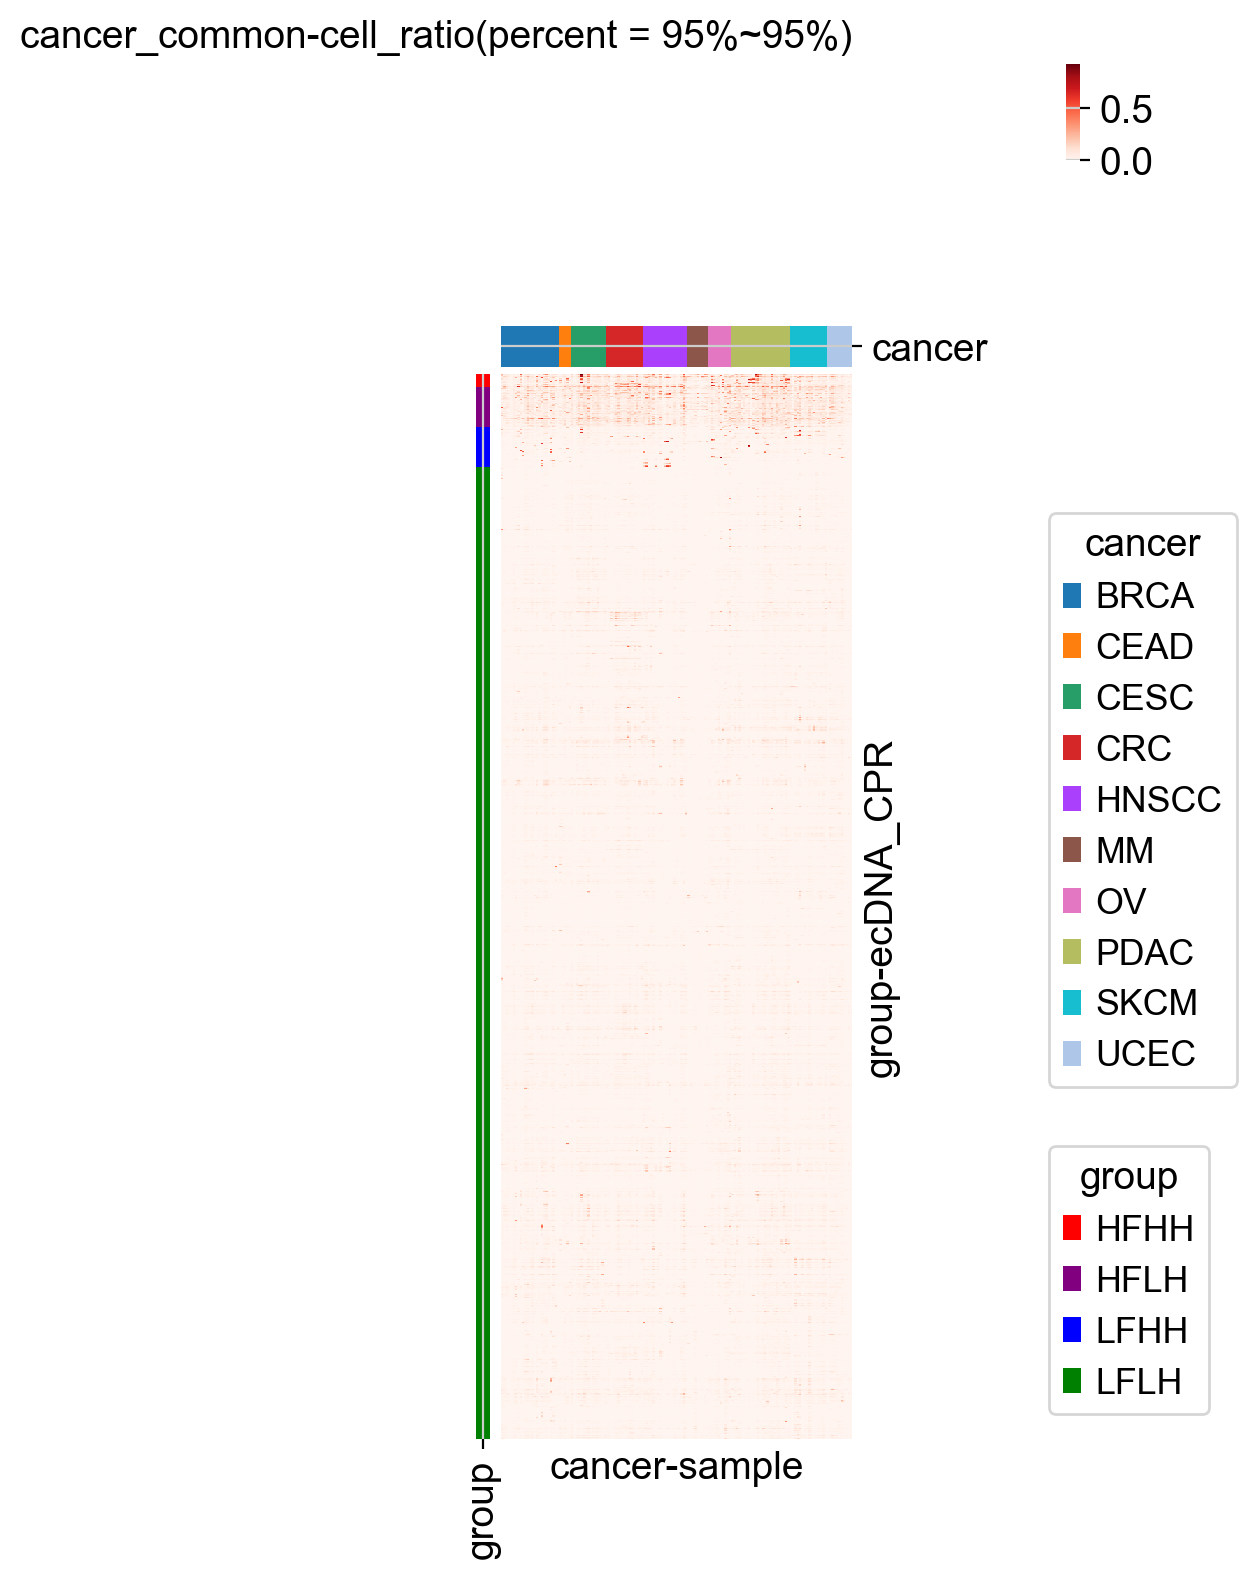

In [138]:
df_mask = df_mtx.copy()
# 生成颜色列表
from matplotlib.colors import to_hex
hex_colors = [to_hex(color) for color in sns.color_palette()]
cancer_pal = sns.color_palette(hex_colors)
group_colors = ["red","purple","blue","green"]
group_pal = sns.color_palette(group_colors)
# 创建颜色映射 columns
cancer_labels = df_mask.columns.get_level_values("cancer")
cancer_lut = dict(zip(map(str, cancer_labels.unique().sort_values()), cancer_pal))
cancer_colors = pd.Series(cancer_labels, index=df_mask.columns).map(cancer_lut)
# 创建颜色映射 index
group_labels = df_mask.index.get_level_values("group")
group_lut = dict(zip(map(str, group_labels.unique().sort_values()), group_pal))
group_colors = pd.Series(group_labels, index=df_mask.index).map(group_lut)

plt.figure(dpi=200)
# 创建clustermap
g = sns.clustermap(df_mask, 
                   #method='complete', #"average","single","complete","weighted","centroid","median","ward",
                   row_cluster=False, 
                   col_cluster=False, 
                   row_colors=group_colors, 
                   col_colors=cancer_colors, 
                   linewidths=0,
                   figsize=(3.5, 8),
                   cmap='Reds',#"vlag"\"Reds"
                   xticklabels=False, yticklabels=False)
from matplotlib.pyplot import gcf
for label in cancer_labels.unique():
    g.ax_col_dendrogram.bar(0, 0, color=cancer_lut[label], label=label, linewidth=0)
l1 = g.ax_col_dendrogram.legend(title='cancer', 
                                loc="center left", 
                                ncol=1, bbox_to_anchor=(1, 0.5),
                                bbox_transform=gcf().transFigure)
for label in group_labels.unique():
    g.ax_row_dendrogram.bar(0, 0, color=group_lut[label], label=label, linewidth=0)
l1 = g.ax_row_dendrogram.legend(title='group', 
                                loc="center left", 
                                ncol=1, bbox_to_anchor=(1, 0.2),
                                bbox_transform=gcf().transFigure)

g.cax.set_position([1.05, 0.9, .02, .06]) # 调整颜色条的位置
#plt.show()
plt.title(f'cancer_common-cell_ratio(percent = 95%~95%)',
          x=-45, y=1)
plt.savefig("./fig_100k_3/cell_frequency_common/f04-df_common_4group_095_095_s-cancer_sample-group_cpr.pdf", bbox_inches='tight')

In [144]:
groups = df_mtx.groupby(level='group')
for _, group in groups:
    print(len(group)) 
sampled_dfs = [group.sample(n=100, replace=True) if len(group) > 100 else group for _, group in groups]
new_df = pd.concat(sampled_dfs)

21
66
66
1586


<Figure size 800x800 with 0 Axes>

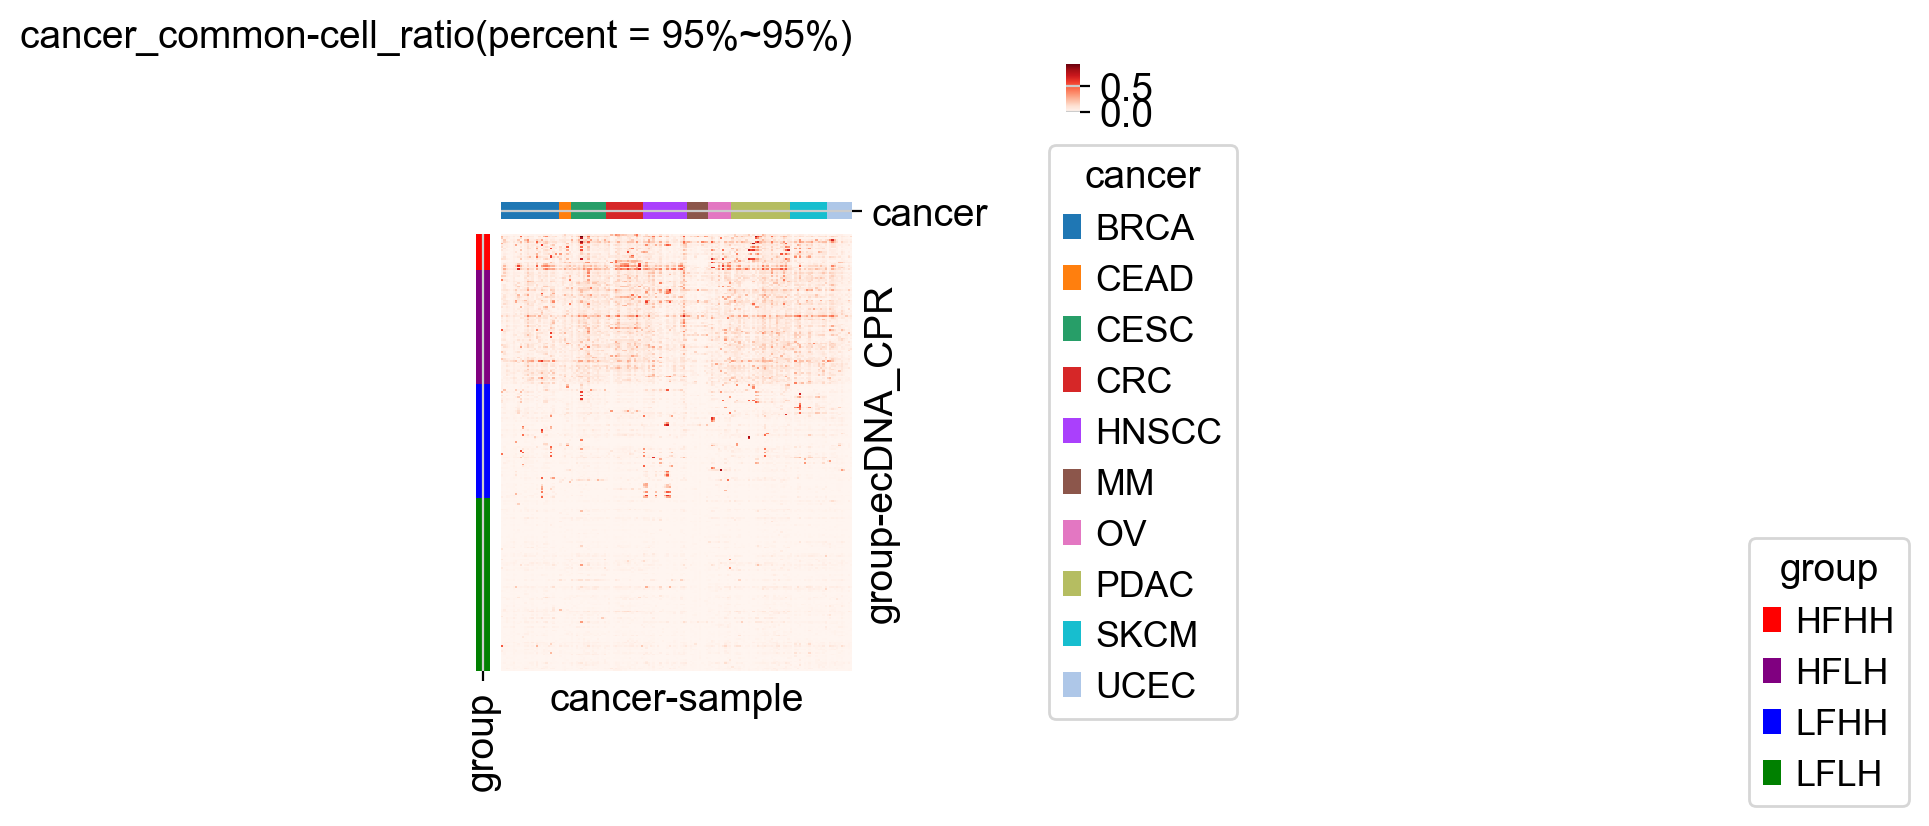

In [148]:
df_mask = new_df.copy()
# 生成颜色列表
from matplotlib.colors import to_hex
hex_colors = [to_hex(color) for color in sns.color_palette()]
cancer_pal = sns.color_palette(hex_colors)
group_colors = ["red","purple","blue","green"]
group_pal = sns.color_palette(group_colors)
# 创建颜色映射 columns
cancer_labels = df_mask.columns.get_level_values("cancer")
cancer_lut = dict(zip(map(str, cancer_labels.unique().sort_values()), cancer_pal))
cancer_colors = pd.Series(cancer_labels, index=df_mask.columns).map(cancer_lut)
# 创建颜色映射 index
group_labels = df_mask.index.get_level_values("group")
group_lut = dict(zip(map(str, group_labels.unique().sort_values()), group_pal))
group_colors = pd.Series(group_labels, index=df_mask.index).map(group_lut)

plt.figure(dpi=200)
# 创建clustermap
g = sns.clustermap(df_mask, 
                   #method='complete', #"average","single","complete","weighted","centroid","median","ward",
                   row_cluster=False, 
                   col_cluster=False, 
                   row_colors=group_colors, 
                   col_colors=cancer_colors, 
                   linewidths=0,
                   figsize=(3.5, 4),
                   cmap='Reds',#"vlag"\"Reds"
                   xticklabels=False, yticklabels=False)
from matplotlib.pyplot import gcf
for label in cancer_labels.unique():
    g.ax_col_dendrogram.bar(0, 0, color=cancer_lut[label], label=label, linewidth=0)
l1 = g.ax_col_dendrogram.legend(title='cancer', 
                                loc="center left", 
                                ncol=1, bbox_to_anchor=(1, 0.5),
                                bbox_transform=gcf().transFigure)
for label in group_labels.unique():
    g.ax_row_dendrogram.bar(0, 0, color=group_lut[label], label=label, linewidth=0)
l1 = g.ax_row_dendrogram.legend(title='group', 
                                loc="center left", 
                                ncol=1, bbox_to_anchor=(2, 0.2),
                                bbox_transform=gcf().transFigure)

g.cax.set_position([1.05, 0.9, .02, .06]) # 调整颜色条的位置
#plt.show()
plt.title(f'cancer_common-cell_ratio(percent = 95%~95%)',
          x=-45, y=1)
plt.savefig("./fig_100k_3/cell_frequency_common/f04-df_common_4group_095_095_s-cancer_sample-group_cpr_short.pdf", bbox_inches='tight')

In [151]:
df_mtx_index = df_mtx.index.to_frame(index=False)
df_mtx_index

,group,ecDNA_CPR
0,HFHH,chr20:62600000_62700000
1,HFHH,chr19:45400000_45500000
2,HFHH,chr19:44700000_44800000
3,HFHH,chr22:46000000_46100000
4,HFHH,chr19:42200000_42300000
...,...,...
1734,LFLH,chr17:73500000_73600000
1735,LFLH,chr17:73300000_73400000
1736,LFLH,chr17:7300000_7400000
1737,LFLH,chr17:75000000_75100000


In [152]:
### anno ecdna2gene oncogene pathway
### import ecdna2gene2pathway function

In [182]:
df_mtx_index["chr_raw"] = df_mtx_index["ecDNA_CPR"]

df_ecdna = df_mtx_index.copy()
df_ecdna_gene = genebody_region(df_fragments=df_ecdna,species="hg38")
df_ecdna_gene['oncogene'] = df_ecdna_gene['genebody_region_gene'].apply(custom_transform)
df_ecdna_gene.to_csv('./fig_100k_3/cell_frequency_common/f05-df_ecdna_gene_oncogene.xls', sep='\t', index=True)
df_ecdna_gene

species value: hg38


,group,ecDNA_CPR,chr_raw,genebody_region,genebody_region_gene,oncogene
0,HFHH,chr20:62600000_62700000,chr20:62600000_62700000,9,"[WI2-87327B8.2, RP13-30A9.1, RP13-30A9.2, RP11...",[]
1,HFHH,chr19:45400000_45500000,chr19:45400000_45500000,7,"[PPP1R13L, CD3EAP, ERCC1, MIR6088, FOSB, RTN2,...",[]
2,HFHH,chr19:44700000_44800000,chr19:44700000_44800000,5,"[CTB-171A8.1, CEACAM16, BCL3, AC092066.6, CBLC]","[BCL3, CBLC]"
3,HFHH,chr22:46000000_46100000,chr22:46000000_46100000,10,"[CITF22-92A6.2, CITF22-92A6.1, LINC00899, PRR3...",[]
4,HFHH,chr19:42200000_42300000,chr19:42200000_42300000,8,"[DEDD2, ZNF526, GSK3A, AC006486.9, AC006486.10...",[CIC]
...,...,...,...,...,...,...
1734,LFLH,chr17:73500000_73600000,chr17:73500000_73600000,2,"[SDK2, RP11-449L23.2]",[]
1735,LFLH,chr17:73300000_73400000,chr17:73300000_73400000,2,"[CDC42EP4, SDK2]",[]
1736,LFLH,chr17:7300000_7400000,chr17:7300000_7400000,11,"[EIF5A, GPS2, RP11-542C16.2, NEURL4, AC026954....",[]
1737,LFLH,chr17:75000000_75100000,chr17:75000000_75100000,10,"[CDR2L, MRPL58, RNU6-362P, KCTD2, AC087651.2, ...",[]


In [184]:
df_merge_onco = group_merge(df_ecdna_gene,"group","oncogene")
# 计算col1列每个元素的长度，并创建新的col2列
df_merge_onco['oncogene_nor_number'] = df_merge_onco['oncogene_nor'].apply(lambda x: len(x))
df_merge_onco.to_csv('./fig_100k_3/cell_frequency_common/f06-df_ecdna_gene_oncogene-df_merge_onco.xls', sep='\t', index=True)
df_merge_onco

,group,oncogene_nor,most_oncogene_nor,oncogene_nor_number
0,HFHH,"[BCL3, CBLC, CIC, HSP90AB1, NFKBIE, ASPSCR1, A...","[ASPSCR1, BCL3, CBLC, CIC, HSP90AB1, NFKBIE]",7
1,HFLH,"[BCL2L12, TFPT, CNOT3, MEN1, NEAT1, MALAT1, MA...","[MALAT1, STK11, BCL2L12, TFPT, CNOT3, MEN1, NE...",17
2,LFHH,"[AKT2, NDRG1, CBLC, PRKACA, ELL, CRTC1, DNM2, ...","[PRKACA, AKT2, NDRG1, CBLC, ELL, CRTC1, DNM2, ...",17
3,LFLH,"[ZNRF3, BCR, BCR, WDCP, SMARCB1, SMARCB1, EWSR...","[PRDM16, NCOR2, BCR, SMARCB1, DGCR8, MYH9, THR...",217


In [185]:
df_merge_body = group_merge(df_ecdna_gene,"group","genebody_region_gene")
# 计算col1列每个元素的长度，并创建新的col2列
df_merge_body['genebody_region_gene_nor_number'] = df_merge_body['genebody_region_gene_nor'].apply(lambda x: len(x))
df_merge_body.to_csv('./fig_100k_3/cell_frequency_common/f06-df_ecdna_gene_oncogene-df_merge_body.xls', sep='\t', index=True)
df_merge_body

,group,genebody_region_gene_nor,most_genebody_region_gene_nor,genebody_region_gene_nor_number
0,HFHH,"[WI2-87327B8.2, RP13-30A9.1, RP13-30A9.2, RP11...","[ASPSCR1, CPSF1, WI2-87327B8.2, RP13-30A9.1, R...",198
1,HFLH,"[PRR12, CTB-33G10.11, RRAS, SCAF1, IRF3, BCL2L...","[RAB40C, FBXL16, MALAT1, STK11, GMEB2, MIR92B,...",660
2,LFHH,"[LRFN1, CTC-246B18.8, GMFG, CTC-246B18.10, SAM...","[MARK4, PPP1R37, NR1D1, RFX1, PRKACA, ARHGAP23...",363
3,LFLH,"[XBP1, CTA-292E10.6, CTA-292E10.8, CTA-292E10....","[SORCS2, CMIP, MICAL3, PRDM16, MEGF6, COL27A1,...",9060


In [ ]:
### pathway

In [244]:
gsea_path = os.getcwd()+"/fig_100k_3/cell_frequency_common/f07-oncogene_pathway"
enrich_list = []
for sample in df_merge_onco["group"].unique():
    print(sample)
    gene_list = df_merge_onco[df_merge_onco["group"]==sample]["oncogene_nor"].to_list()[0]
    enr_res_temp = gp_enrichr(gene_list=gene_list,sample=sample,path=gsea_path)
    print("done.")
    enrich_list.append(enr_res_temp)
    pass

HFHH
done.
HFLH
done.
LFHH
done.
LFLH
done.


In [245]:
enr_res_onco = pd.concat(enrich_list)
enr_res_onco["cluster"] = pd.Categorical(enr_res_onco["cluster"],
                                      categories=list(enr_res_onco["cluster"].unique())[::-1],
                                      ordered=True)
enr_res_onco.to_csv('./fig_100k_3/cell_frequency_common/f08-gene-pathway.xls', sep='\t', index=True)

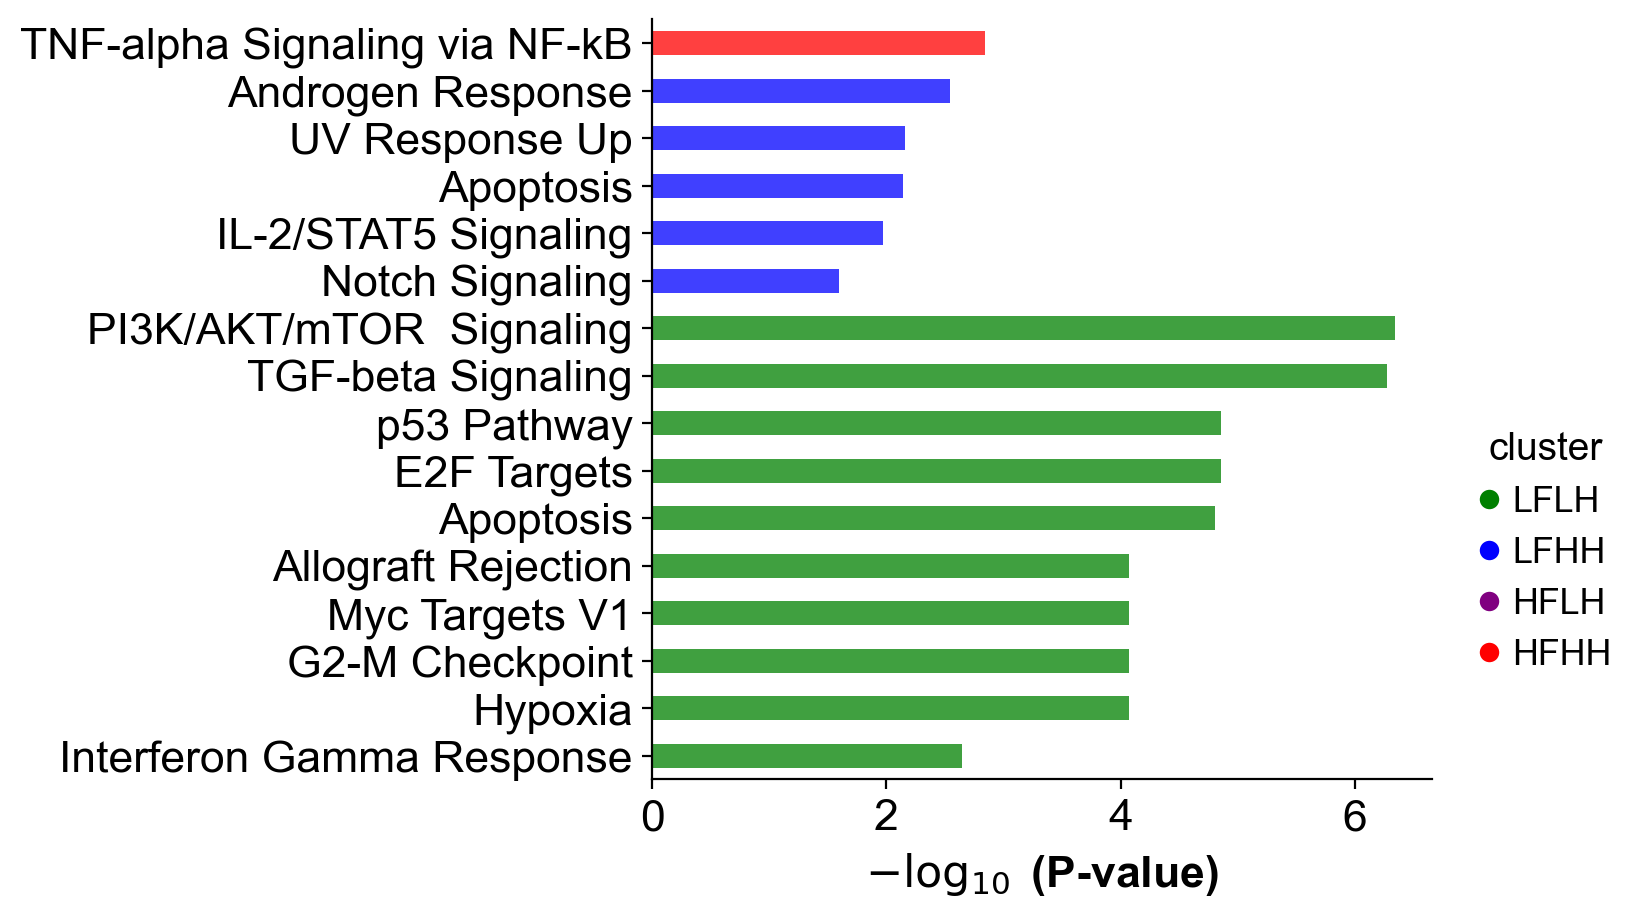

In [261]:
ax = barplot(enr_res_onco,
             #column="Adjusted P-value",
             column="P-value",
             group ='cluster',
             #group='Gene_set', # set group, so you could do a multi-sample/library comparsion
             size=0.2,
             top_term=10,
             #figsize=(10,6*len(enr.results[enr.results["P-value"] <= 0.05])/50),
             figsize=(5,5),
             color=['red','purple','blue',"green"][::-1] # set colors for group
             #color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
             )
plt.grid(False)
plt.savefig('./fig_100k_3/cell_frequency_common/f07-oncogene-pathway.pdf', bbox_inches='tight')

In [236]:
## genebody gene

In [247]:
## genebody gene
gsea_path = os.getcwd()+"/fig_100k_3/cell_frequency_common/f08-gene_pathway"
enrich_list = []
for sample in df_merge_body["group"].unique():
    print(sample)
    gene_list = df_merge_body[df_merge_body["group"]==sample]["genebody_region_gene_nor"].to_list()[0]
    enr_res_temp = gp_enrichr(gene_list=gene_list,sample=sample,path=gsea_path)
    print("done.")
    enrich_list.append(enr_res_temp)
    pass

HFHH
done.
HFLH
done.
LFHH
done.
LFLH
done.


In [248]:
enr_res_gene = pd.concat(enrich_list)
enr_res_gene["cluster"] = pd.Categorical(enr_res_gene["cluster"],
                                      categories=list(enr_res_gene["cluster"].unique())[::-1],
                                      ordered=True)
enr_res_gene.to_csv('./fig_100k_3/cell_frequency_common/f08-gene-pathway.xls', sep='\t', index=True)

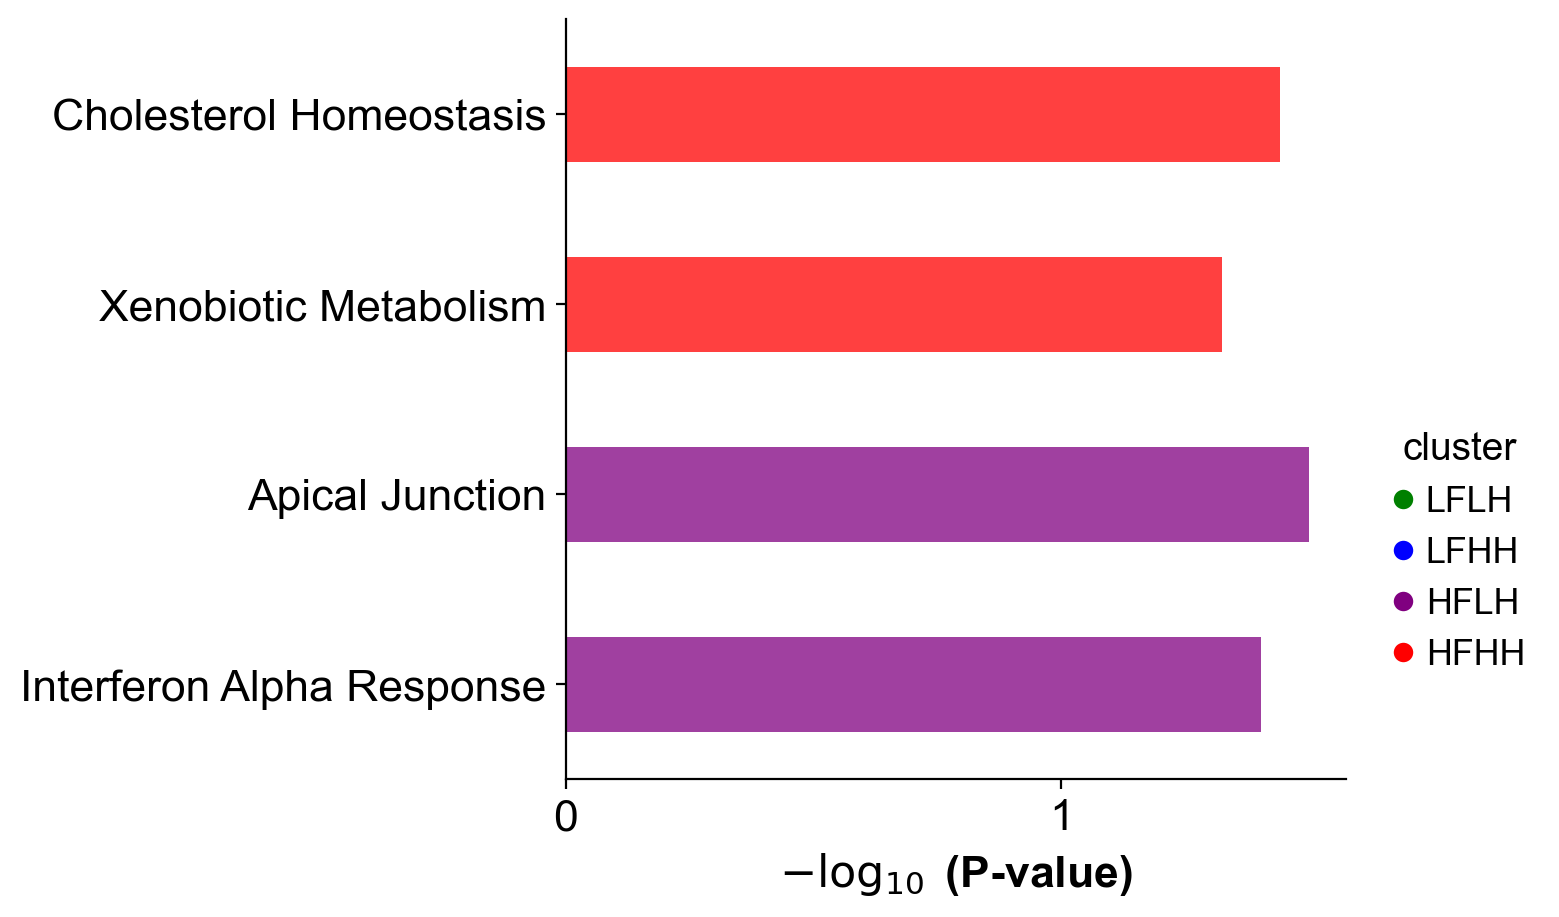

In [262]:
ax = barplot(enr_res_gene,
             #column="Adjusted P-value",
             column="P-value",
             group ='cluster',
             #group='Gene_set', # set group, so you could do a multi-sample/library comparsion
             size=0.2,
             top_term=10,
             #figsize=(10,6*len(enr.results[enr.results["P-value"] <= 0.05])/50),
             figsize=(5,5),
             color=['red','purple','blue',"green"][::-1] # set colors for group
             #color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
             )
plt.grid(False)
plt.savefig('./fig_100k_3/cell_frequency_common/f08-gene-pathway.pdf', bbox_inches='tight')

In [ ]:
### merge onco gene

In [254]:
### merge onco gene
enr_res_onco
enr_res_gene
df_combined = pd.concat([enr_res_onco, enr_res_gene])
df_combined

,Gene_set,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,Term_raw,cluster
0,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,2/200,0.001454,0.005814,0,0,49.989899,326.620610,BCL3;NFKBIE,TNF-alpha Signaling via NF-kB,HFHH
1,MSigDB_Hallmark_2020,G2-M Checkpoint,1/200,0.058527,0.058527,0,0,19.894472,56.465918,BCL3,G2-M Checkpoint,HFHH
2,MSigDB_Hallmark_2020,Myc Targets V1,1/200,0.058527,0.058527,0,0,19.894472,56.465918,HSP90AB1,Myc Targets V1,HFHH
3,MSigDB_Hallmark_2020,Allograft Rejection,1/200,0.058527,0.058527,0,0,19.894472,56.465918,BCL3,Allograft Rejection,HFHH
0,MSigDB_Hallmark_2020,Pperoxisome,1/104,0.075249,0.139987,0,0,13.787795,35.668392,HRAS,Pperoxisome,HFLH
...,...,...,...,...,...,...,...,...,...,...,...,...
45,MSigDB_Hallmark_2020,Fatty Acid Metabolism,30/158,0.999995,0.999995,0,0,0.311007,0.000002,GCDH;ACAA2;ECHS1;ECI1;ODC1;AQP7;UBE2L6;ENO3;AC...,Fatty Acid Metabolism,LFLH
46,MSigDB_Hallmark_2020,UV Response Dn,29/144,0.999995,0.999995,0,0,0.334970,0.000002,CDKN1B;INSIG1;ITGB3;SERPINE1;CACNA1A;ATXN1;RXR...,UV Response Dn,LFLH
47,MSigDB_Hallmark_2020,Spermatogenesis,24/135,0.999995,0.999995,0,0,0.287140,0.000001,TKTL1;GSTM3;HBZ;PRM2;ACE;HSPA1L;CHRM4;TALDO1;T...,Spermatogenesis,LFLH
48,MSigDB_Hallmark_2020,Androgen Response,17/100,0.999995,0.999995,0,0,0.272453,0.000001,UBE2I;INSIG1;SRF;KRT8;TMPRSS2;HSD17B14;PA2G4;N...,Androgen Response,LFLH


In [256]:
enr_res_merge = df_combined.copy()
enr_res_merge["cluster"] = pd.Categorical(enr_res_merge["cluster"],
                                      categories=list(enr_res_merge["cluster"].unique())[::-1],
                                      ordered=True)
enr_res_merge.to_csv('./fig_100k_3/cell_frequency_common/f09-merge-pathway.xls', sep='\t', index=True)

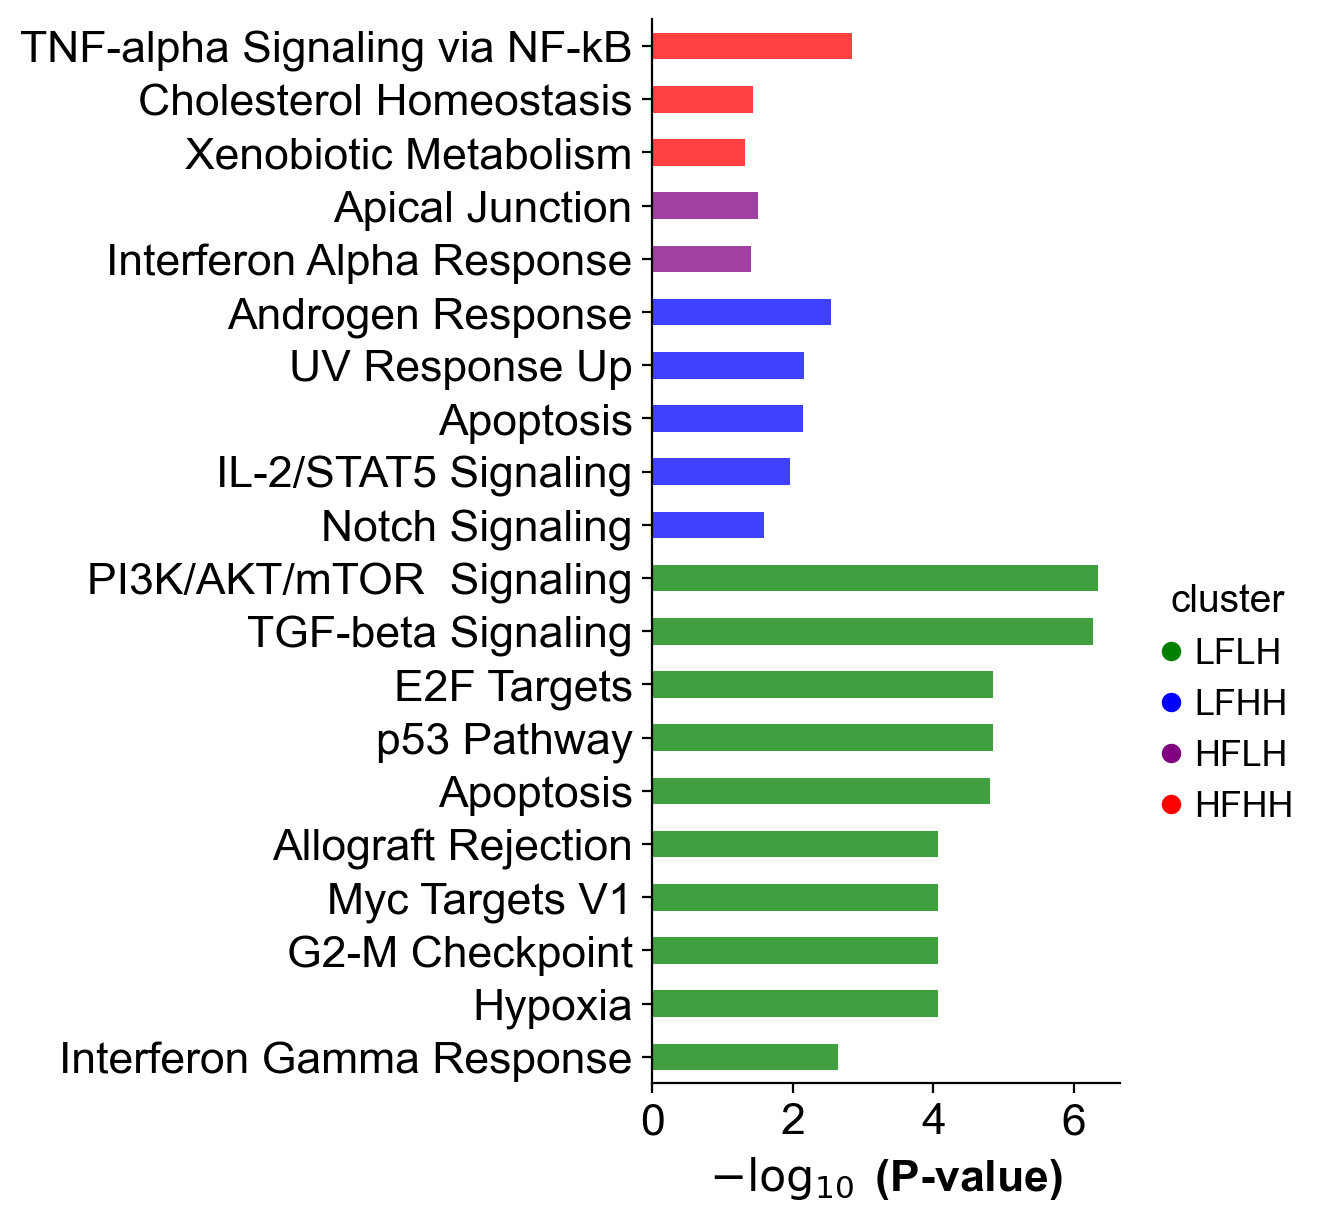

In [267]:
ax = barplot(enr_res_merge,
             #column="Adjusted P-value",
             column="P-value",
             group ='cluster',
             #group='Gene_set', # set group, so you could do a multi-sample/library comparsion
             size=0.2,
             top_term=10,
             #figsize=(10,6*len(enr.results[enr.results["P-value"] <= 0.05])/50),
             figsize=(3,7),
             color=['red','purple','blue',"green"][::-1] # set colors for group
             #color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
             )
plt.grid(False)
plt.savefig('./fig_100k_3/cell_frequency_common/f09-merge-pathway.pdf', bbox_inches='tight')

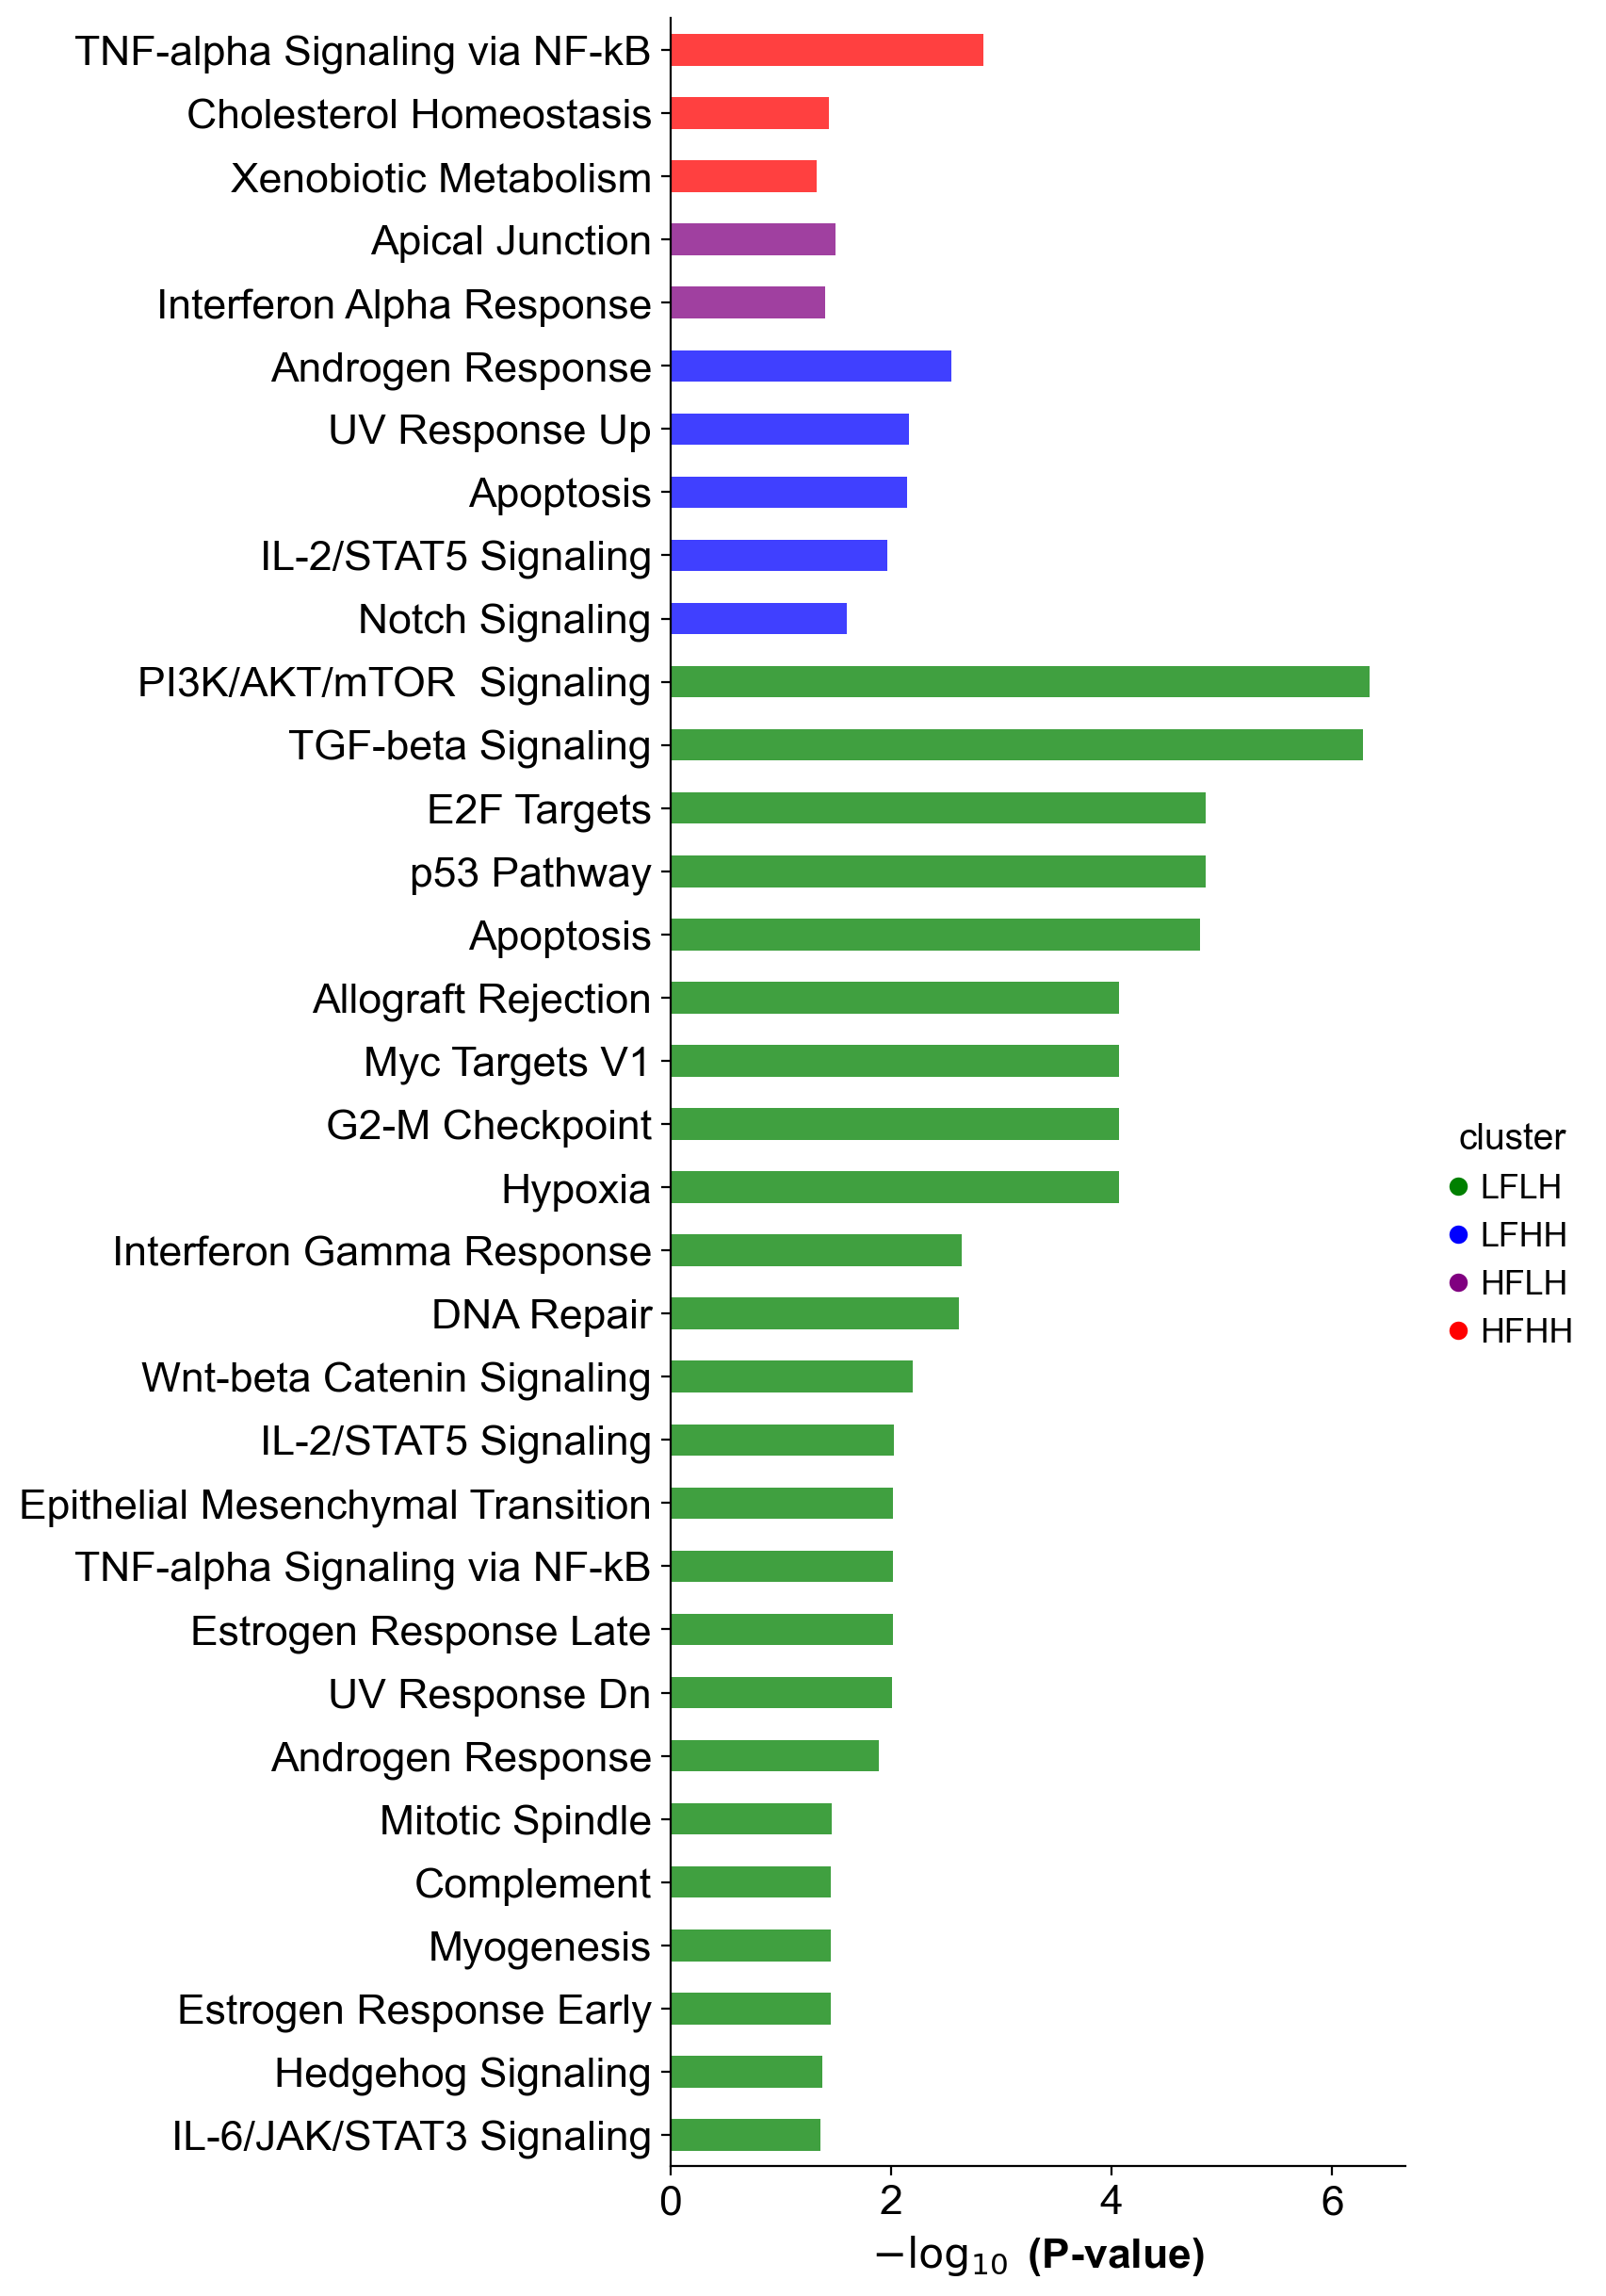

In [266]:
ax = barplot(enr_res_merge,
             #column="Adjusted P-value",
             column="P-value",
             group ='cluster',
             #group='Gene_set', # set group, so you could do a multi-sample/library comparsion
             size=0.2,
             top_term=50,
             #figsize=(10,6*len(enr.results[enr.results["P-value"] <= 0.05])/50),
             figsize=(5,15),
             color=['red','purple','blue',"green"][::-1] # set colors for group
             #color = {'KEGG_2021_Human': 'salmon', 'MSigDB_Hallmark_2020':'darkblue'}
             )
plt.grid(False)
plt.savefig('./fig_100k_3/cell_frequency_common/f09-merge-pathway_2.pdf', bbox_inches='tight')